<h1 style="text-align:center; font-family:Arial, sans-serif; color:green; font-weight:bold; font-size:36px; margin-top:40px;">
  🕵️‍♂️ Fraud Detection Transactions Dataset
</h1>

### <span style="color:green">Project Overview</span> 
> This project aims to build a machine learning model to classify fraudulent transactions using a synthetic dataset of 50,000 records.

> Key features such as Risk Score, Transaction Amount, and Failed Transaction Count (7 days) were analyzed to train a binary classification model.

> Although Linear Regression showed slightly higher accuracy, it was not used due to its unsuitability for binary outcomes. Instead, Logistic Regression was selected as the primary model, achieving strong performance and better alignment with the classification task.

> The project utilized Python for model development and Tableau for visual analysis and reporting.
</h2>

In [175]:
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.api as sm



from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


sns.set_style("darkgrid")
mpl.rcParams['figure.figsize'] = (20,5)

# Part 1: <span style="color:green">Exploratory Data Analysis</span>


### Step 1: <span style="color:green">Import Libraries</span> 

Import the libraries you'll need for your analysis. You will need the following libraries: 

**Matplotlib** - This is Python's basic plotting library.
You'll use the pyplot and dates function collections from matplotlib throughout this case study so we encourage you to important these two specific libraries with their own aliases. Also, include the line **'%matplotlib inline'** so that your graphs are easily included in your notebook. 

**Seaborn** - This library will enable you to create aesthetically pleasing plots.

**Pandas** - This library will enable you to view and manipulate your data in a tabular format.

**statsmodels.api** - This library will enable you to create statistical models. You will need this library when performing regession analysis in Part 2 of this case study.

Please note we've included the necessary libraries below for you to help you get started!

This code controls how big your charts will be with the syntax of (X,Y) where X represents the X Axis and Y, the Y Axis.

In [181]:
df = pd.read_csv("synthetic_fraud_dataset.csv")
print(df.shape)

(50000, 21)


In [999]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

In [1001]:
print(df.head())

  Transaction_ID    User_ID  Transaction_Amount Transaction_Type  \
0      TXN_33553  USER_1834               39.79              POS   
1       TXN_9427  USER_7875                1.19    Bank Transfer   
2        TXN_199  USER_2734               28.96           Online   
3      TXN_12447  USER_2617              254.32   ATM Withdrawal   
4      TXN_39489  USER_2014               31.28              POS   

             Timestamp  Account_Balance Device_Type  Location  \
0  2023-08-14 19:30:00         93213.17      Laptop    Sydney   
1  2023-06-07 04:01:00         75725.25      Mobile  New York   
2  2023-06-20 15:25:00          1588.96      Tablet    Mumbai   
3  2023-12-07 00:31:00         76807.20      Tablet  New York   
4  2023-11-11 23:44:00         92354.66      Mobile    Mumbai   

  Merchant_Category  IP_Address_Flag  ...  Daily_Transaction_Count  \
0            Travel                0  ...                        7   
1          Clothing                0  ...                   

In [1003]:
print(df.describe())

       Transaction_Amount  Account_Balance  IP_Address_Flag  \
count        50000.000000     50000.000000      50000.00000   
mean            99.411012     50294.065981          0.05020   
std             98.687292     28760.458557          0.21836   
min              0.000000       500.480000          0.00000   
25%             28.677500     25355.995000          0.00000   
50%             69.660000     50384.430000          0.00000   
75%            138.852500     75115.135000          0.00000   
max           1174.140000     99998.310000          1.00000   

       Previous_Fraudulent_Activity  Daily_Transaction_Count  \
count                  50000.000000             50000.000000   
mean                       0.098400                 7.485240   
std                        0.297858                 4.039637   
min                        0.000000                 1.000000   
25%                        0.000000                 4.000000   
50%                        0.000000             

In [485]:
print(df.dtypes)

Transaction_ID                   object
User_ID                          object
Transaction_Amount              float64
Transaction_Type                 object
Timestamp                        object
Account_Balance                 float64
Device_Type                      object
Location                         object
Merchant_Category                object
IP_Address_Flag                   int64
Previous_Fraudulent_Activity      int64
Daily_Transaction_Count           int64
Avg_Transaction_Amount_7d       float64
Failed_Transaction_Count_7d       int64
Card_Type                        object
Card_Age                          int64
Transaction_Distance            float64
Authentication_Method            object
Risk_Score                      float64
Is_Weekend                        int64
Fraud_Label                       int64
dtype: object


In [369]:
print(df['Transaction_Type'].value_counts())

Transaction_Type
POS               12549
Online            12546
ATM Withdrawal    12453
Bank Transfer     12452
Name: count, dtype: int64


In [371]:
df.isna().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

In [204]:
print(df["Fraud_Label"].isna().sum())

0


**Splitting Timestamp Column** - Spliting Timestamp column into two separate columns: one for the date and one for the time, using pandas' pd.to_datetime to ensure that the column is in datetime format and then extract the date and time parts using the .dt accessor.


In [56]:
# Split the 'Timestamp' column into Date and Time Columns
df['Timestamp'] = pd.to_datetime(df['Timestamp'])  # Ensure it's in datetime format

# Create a 'Date' column by extracting the date part
df['Date'] = df['Timestamp'].dt.date

# Create a 'Time' column by extracting the time part
df['Time'] = df['Timestamp'].dt.time

# Optionally, display the first few rows to check the result
print(df[['Timestamp', 'Date', 'Time']].head())

            Timestamp        Date      Time
0 2023-08-14 19:30:00  2023-08-14  19:30:00
1 2023-06-07 04:01:00  2023-06-07  04:01:00
2 2023-06-20 15:25:00  2023-06-20  15:25:00
3 2023-12-07 00:31:00  2023-12-07  00:31:00
4 2023-11-11 23:44:00  2023-11-11  23:44:00


Fraud_Label
0    33933
1    16067
Name: count, dtype: int64


C:\Users\moham\AppData\Local\Temp\ipykernel_21936\1643522616.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fraud_Label', data=df, palette='YlGnBu')


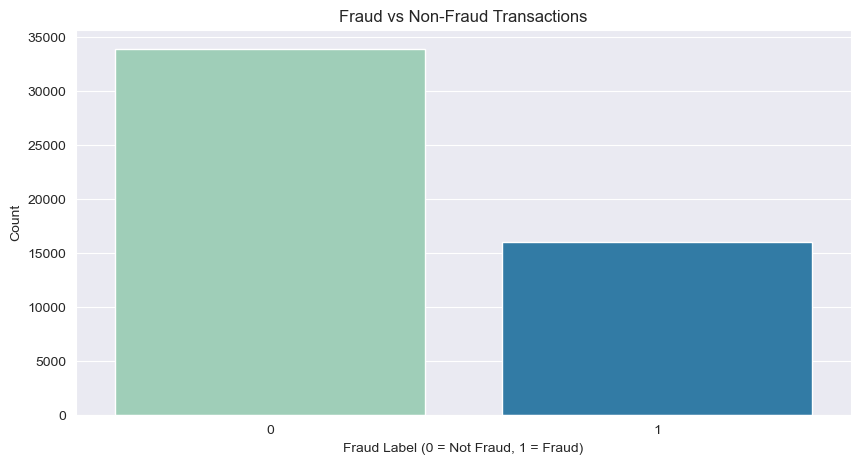

In [8]:
print(df['Fraud_Label'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(x='Fraud_Label', data=df, palette='YlGnBu')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Label (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

Fraud Transactions by Merchant Category:

Merchant_Category
Restaurants    3255
Travel         3235
Groceries      3217
Clothing       3181
Electronics    3179
Name: count, dtype: int64

Non-Fraud Transactions by Merchant Category:

Merchant_Category
Clothing       6852
Groceries      6802
Travel         6780
Electronics    6778
Restaurants    6721
Name: count, dtype: int64


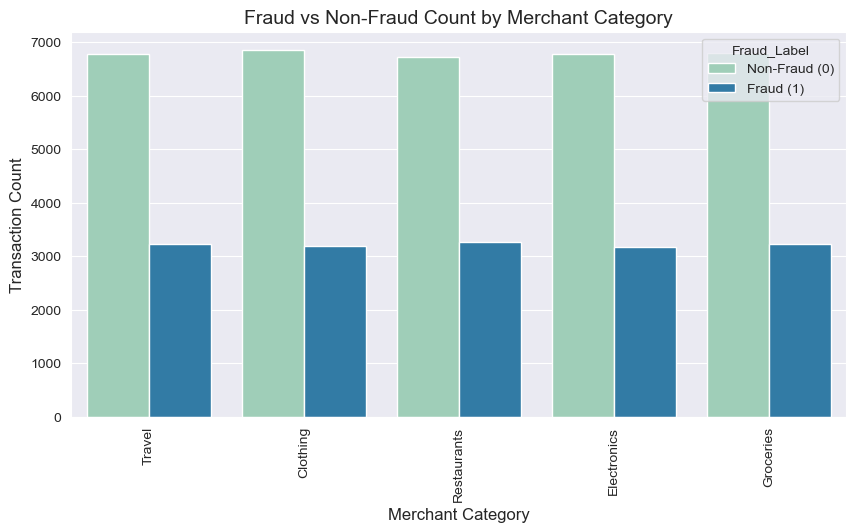

In [10]:
# Step 1: Print fraud and non-fraud transaction counts per Merchant Category
fraud_counts = df[df['Fraud_Label'] == 1]['Merchant_Category'].value_counts(ascending=False)
non_fraud_counts = df[df['Fraud_Label'] == 0]['Merchant_Category'].value_counts(ascending=False)

print("Fraud Transactions by Merchant Category:\n")
print(fraud_counts)

print("\nNon-Fraud Transactions by Merchant Category:\n")
print(non_fraud_counts)

# Step 2: Create a count plot for all transactions, distinguishing Fraud vs Non-Fraud
plt.figure(figsize=(10, 5))
sns.countplot(x='Merchant_Category', hue='Fraud_Label', data=df, palette='YlGnBu')

# Step 3: Customize the plot
plt.xticks(rotation=90)  # Rotate for better readability if needed
plt.title("Fraud vs Non-Fraud Count by Merchant Category", fontsize=14)
plt.xlabel("Merchant Category", fontsize=12)
plt.ylabel("Transaction Count", fontsize=12)
plt.legend(title="Fraud_Label", labels=["Non-Fraud (0)", "Fraud (1)"])  # Clear legend

# Step 4: Show the plot
plt.show()

Fraud Transactions by Device_Type:

Device_Type
Tablet    5464
Mobile    5305
Laptop    5298
Name: count, dtype: int64

Non-Fraud Transactions by Merchant Category:

Device_Type
Mobile    11335
Tablet    11315
Laptop    11283
Name: count, dtype: int64


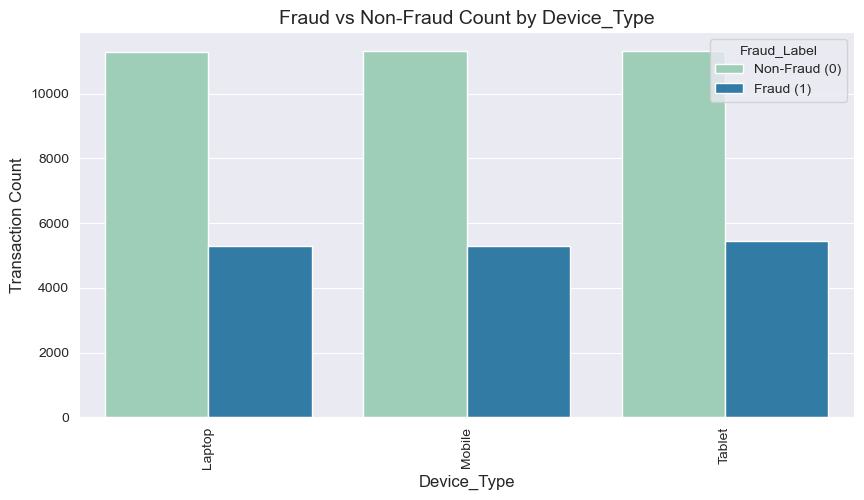

In [12]:
# Step 1: Print fraud and non-fraud transaction counts per Merchant Category
fraud_counts = df[df['Fraud_Label'] == 1]['Device_Type'].value_counts(ascending=False)
non_fraud_counts = df[df['Fraud_Label'] == 0]['Device_Type'].value_counts(ascending=False)

print("Fraud Transactions by Device_Type:\n")
print(fraud_counts)

print("\nNon-Fraud Transactions by Merchant Category:\n")
print(non_fraud_counts)

# Step 2: Create a count plot for all transactions, distinguishing Fraud vs Non-Fraud
plt.figure(figsize=(10, 5))
sns.countplot(x='Device_Type', hue='Fraud_Label', data=df, palette='YlGnBu')

# Step 3: Customize the plot
plt.xticks(rotation=90)  # Rotate for better readability if needed
plt.title("Fraud vs Non-Fraud Count by Device_Type", fontsize=14)
plt.xlabel("Device_Type", fontsize=12)
plt.ylabel("Transaction Count", fontsize=12)
plt.legend(title="Fraud_Label", labels=["Non-Fraud (0)", "Fraud (1)"])  # Clear legend

# Step 4: Show the plot
plt.show()

Fraud Transactions by Location:

Location
Tokyo       3315
New York    3221
Sydney      3194
London      3181
Mumbai      3156
Name: count, dtype: int64

Non-Fraud Transactions by Location:

Location
Tokyo       6893
Mumbai      6838
London      6764
Sydney      6744
New York    6694
Name: count, dtype: int64


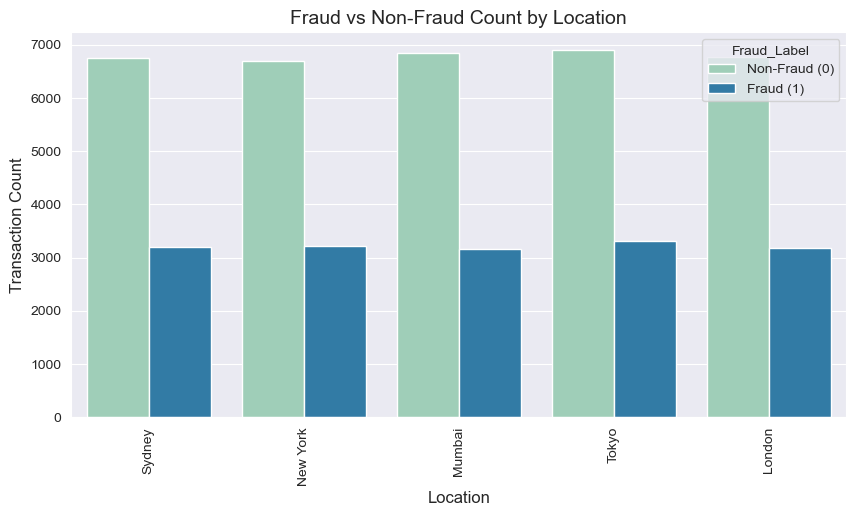

In [14]:
# Step 1: Print fraud and non-fraud transaction counts per Merchant Category
fraud_counts = df[df['Fraud_Label'] == 1]['Location'].value_counts(ascending=False)
non_fraud_counts = df[df['Fraud_Label'] == 0]['Location'].value_counts(ascending=False)

print("Fraud Transactions by Location:\n")
print(fraud_counts)

print("\nNon-Fraud Transactions by Location:\n")
print(non_fraud_counts)

# Step 2: Create a count plot for all transactions, distinguishing Fraud vs Non-Fraud
plt.figure(figsize=(10, 5))
sns.countplot(x='Location', hue='Fraud_Label', data=df, palette='YlGnBu')

# Step 3: Customize the plot
plt.xticks(rotation=90)  # Rotate for better readability if needed
plt.title("Fraud vs Non-Fraud Count by Location", fontsize=14)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Transaction Count", fontsize=12)
plt.legend(title="Fraud_Label", labels=["Non-Fraud (0)", "Fraud (1)"])  # Clear legend

# Step 4: Show the plot
plt.show()

Is_Weekend
0    11252
1     4815
Name: count, dtype: int64


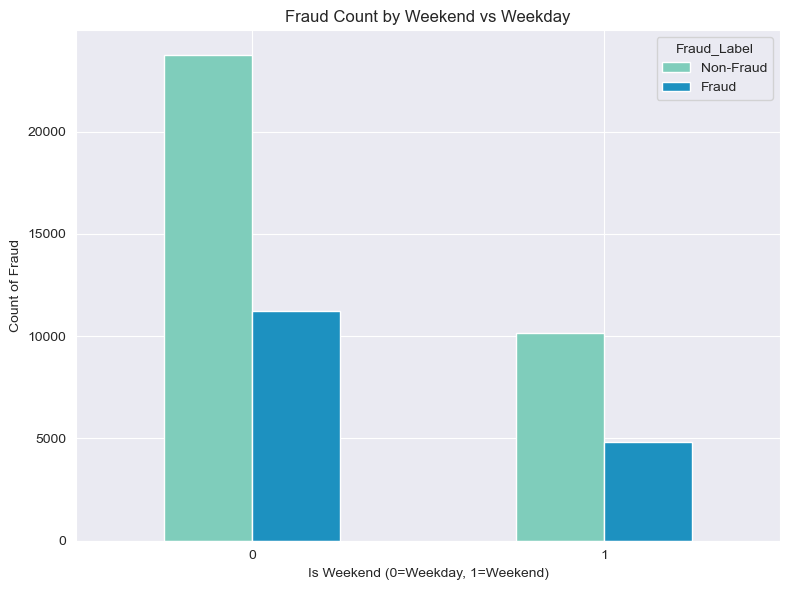

In [26]:
df_fraud = df[df['Fraud_Label'] == 1]
print(df_fraud['Is_Weekend'].value_counts(ascending=False))


# Group by Is_Weekend and Fraud_Label to count occurrences of fraud by Is_Weekend
fraud_by_weekend = df.groupby(['Is_Weekend', 'Fraud_Label']).size().unstack(fill_value=0)

# Plot a bar graph for Fraud_Label count by Is_Weekend
plt.figure(figsize=(8, 6))
fraud_by_weekend.plot(kind='bar', stacked=False, color=['#7FCDBB', '#1D91C0'], ax=plt.gca()) #
plt.title("Fraud Count by Weekend vs Weekday")
plt.xlabel("Is Weekend (0=Weekday, 1=Weekend)")
plt.ylabel("Count of Fraud")
plt.xticks(rotation=0)  # Keep the x-axis labels horizontal
plt.legend(title='Fraud_Label', labels=['Non-Fraud', 'Fraud'])
plt.tight_layout()  # Adjust layout to prevent label clipping
plt.show()

Fraud Transactions by Transaction_Type:

Transaction_Type
ATM Withdrawal    4046
Online            4031
Bank Transfer     3995
POS               3995
Name: count, dtype: int64

Non-Fraud Transactions by Transaction_Type:

Transaction_Type
POS               8554
Online            8515
Bank Transfer     8457
ATM Withdrawal    8407
Name: count, dtype: int64


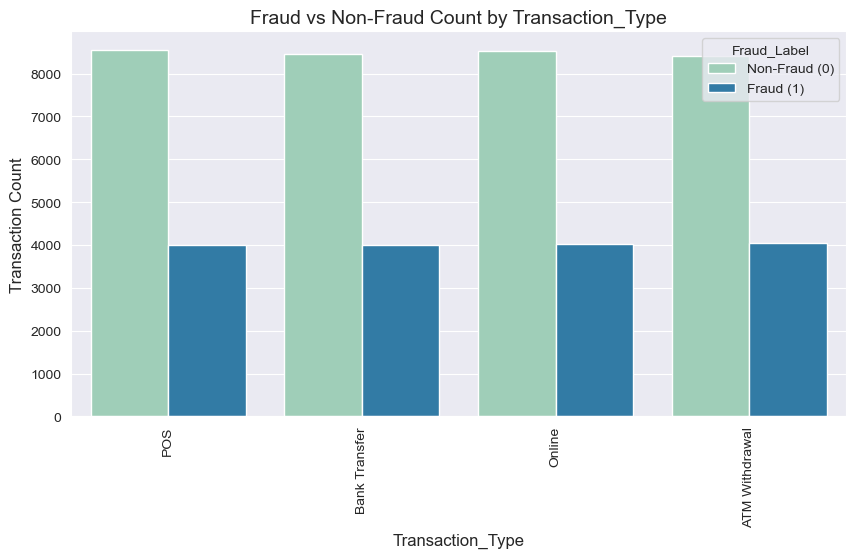

In [28]:
# Step 1: Print fraud and non-fraud transaction counts per Merchant Category
fraud_counts = df[df['Fraud_Label'] == 1]['Transaction_Type'].value_counts(ascending=False)
non_fraud_counts = df[df['Fraud_Label'] == 0]['Transaction_Type'].value_counts(ascending=False)

print("Fraud Transactions by Transaction_Type:\n")
print(fraud_counts)

print("\nNon-Fraud Transactions by Transaction_Type:\n")
print(non_fraud_counts)

# Step 2: Create a count plot for all transactions, distinguishing Fraud vs Non-Fraud
plt.figure(figsize=(10, 5))
sns.countplot(x='Transaction_Type', hue='Fraud_Label', data=df, palette='YlGnBu')

# Step 3: Customize the plot
plt.xticks(rotation=90)  # Rotate for better readability if needed
plt.title("Fraud vs Non-Fraud Count by Transaction_Type", fontsize=14)
plt.xlabel("Transaction_Type", fontsize=12)
plt.ylabel("Transaction Count", fontsize=12)
plt.legend(title="Fraud_Label", labels=["Non-Fraud (0)", "Fraud (1)"])  # Clear legend

# Step 4: Show the plot
plt.show()

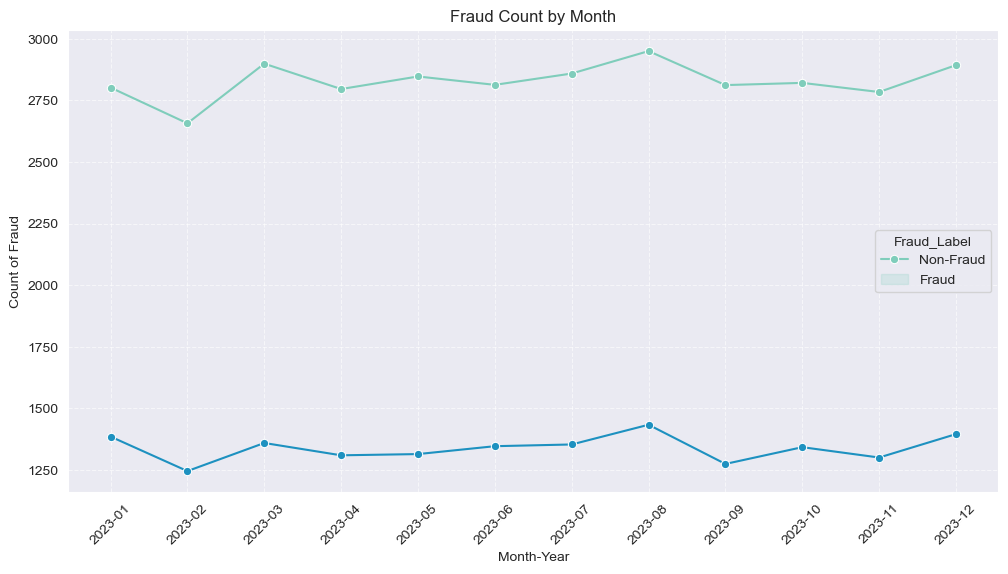

In [32]:
# Extract Month-Year from Timestamp
df['Month_Year'] = pd.to_datetime(df['Timestamp']).dt.to_period('M')  # This creates a Month-Year period

# Group by Month-Year and Fraud_Label to count occurrences of fraud by Month
fraud_by_month = df.groupby(['Month_Year', 'Fraud_Label']).size().unstack(fill_value=0)

# Plot a line plot for Fraud_Label by Month
plt.figure(figsize=(12, 6))

# Line plot with specified colors
sns.lineplot(data=fraud_by_month, x=fraud_by_month.index.astype(str), y=0, label='Non-Fraud', marker='o', color='#7FCDBB')
sns.lineplot(data=fraud_by_month, x=fraud_by_month.index.astype(str), y=1, label='Fraud', marker='o', color='#1D91C0')

# Formatting the plot
plt.title("Fraud Count by Month")
plt.xlabel("Month-Year")
plt.ylabel("Count of Fraud")
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
plt.legend(title='Fraud_Label', labels=['Non-Fraud', 'Fraud'])
plt.grid(True, linestyle='--', alpha=0.6)  # Add a light grid for readability

plt.show()

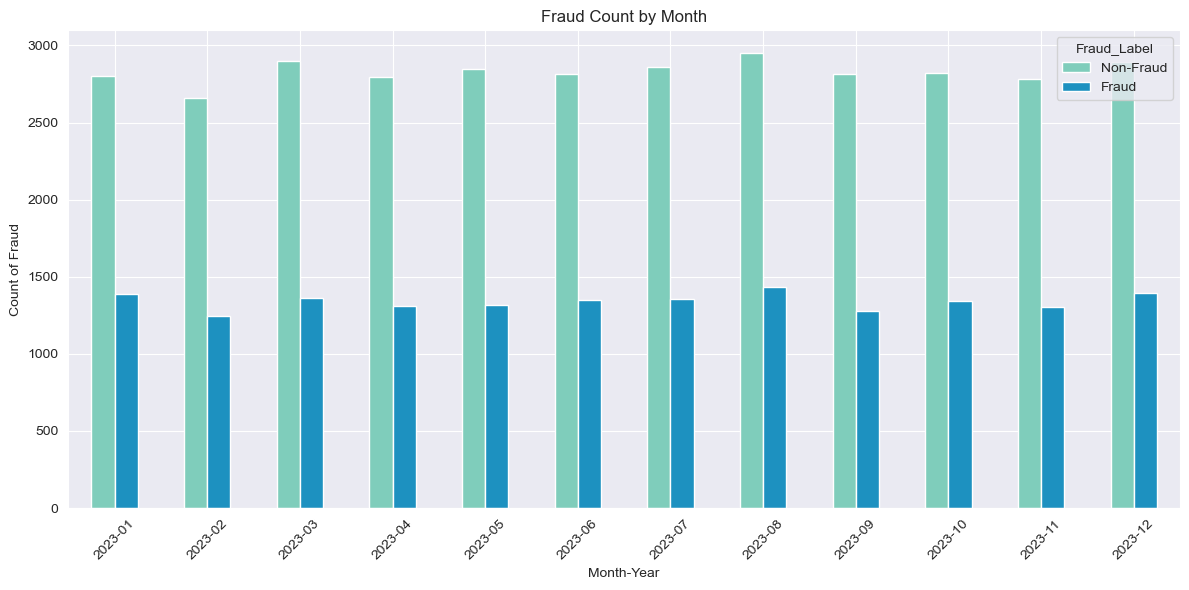

In [36]:
# Extract Month-Year from Timestamp
df['Month_Year'] = pd.to_datetime(df['Timestamp']).dt.to_period('M')  # This creates a Month-Year period

# Group by Month-Year and Fraud_Label to count occurrences of fraud by Month
fraud_by_month = df.groupby(['Month_Year', 'Fraud_Label']).size().unstack(fill_value=0)

# Plot a bar plot for Fraud_Label by Month
plt.figure(figsize=(12, 6))
fraud_by_month.plot(kind='bar', stacked=False, color=['#7FCDBB', '#1D91C0'], ax=plt.gca())  # Using correct colors

# Formatting the plot
plt.title("Fraud Count by Month")
plt.xlabel("Month-Year")
plt.ylabel("Count of Fraud")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='Fraud_Label', labels=['Non-Fraud', 'Fraud'])
plt.tight_layout()  # Adjust layout to prevent label clipping

plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_26736\2003452888.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')  # Converts only valid numbers


Numeric Variables: ['Fraud_Label', 'Risk_Score', 'Failed_Transaction_Count_7d']


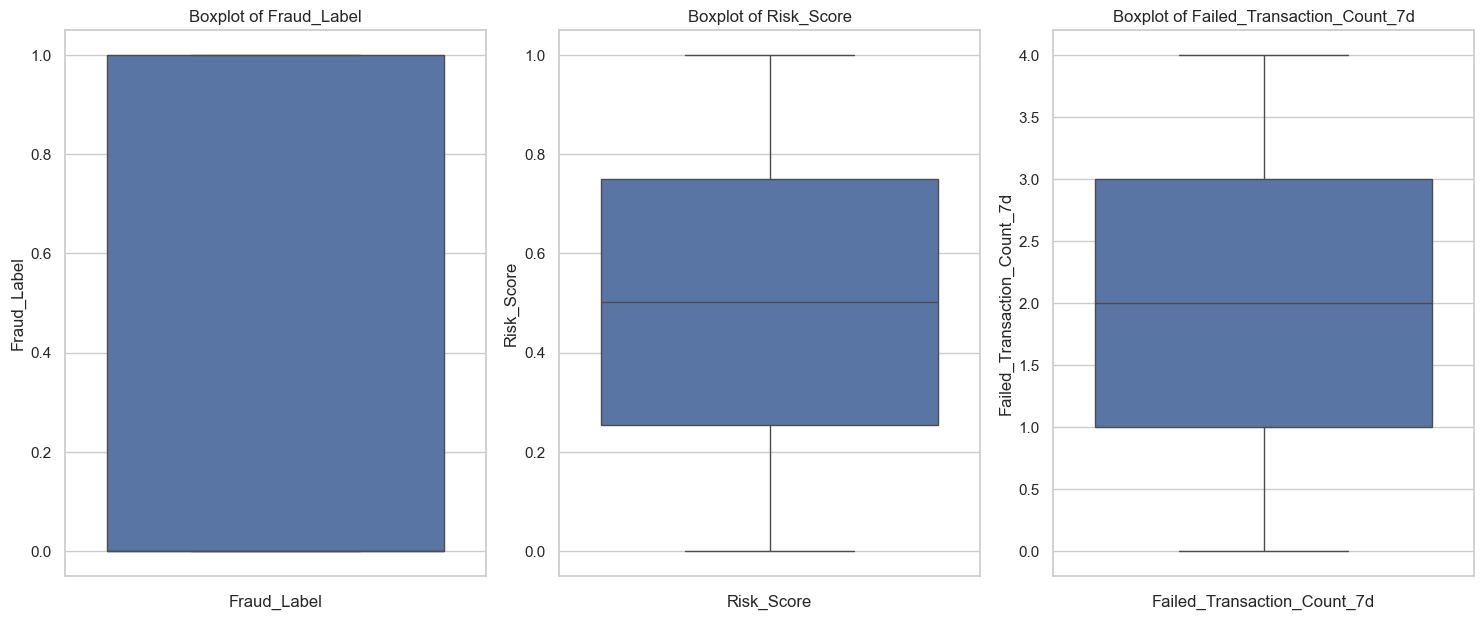

In [364]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure column names are cleaned
df.columns = df.columns.str.strip().str.replace(' ', '_')  # Normalize column names

# Convert any numeric-looking columns to numeric (if possible)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')  # Converts only valid numbers

# Select only numerical variables
numerical_variables = df.select_dtypes(include=['number']).columns.tolist()

# Print the selected numeric columns for verification
print("Numeric Variables:", numerical_variables)

# Set up the plot
plt.figure(figsize=(15, 12))  # Adjust figure size for better visibility

# Determine the number of subplots needed
num_vars = len(numerical_variables)
rows = (num_vars // 3) + 1  # Ensure enough rows for all variables

# Plot box plots for each numerical variable
for i, var in enumerate(numerical_variables, 1):
    plt.subplot(rows, 3, i)  # Creating a grid (3 columns per row)
    sns.boxplot(data=df, y=var)  # Use y instead of x for numeric data
    plt.title(f'Boxplot of {var}')
    plt.xlabel(var)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()




## Optimized Code for Categorical and Numerical Relationships with Fraud_Label

### Boxplots for Numerical Variables vs. Fraud_Label – showing the distribution of numerical features based on fraud status.

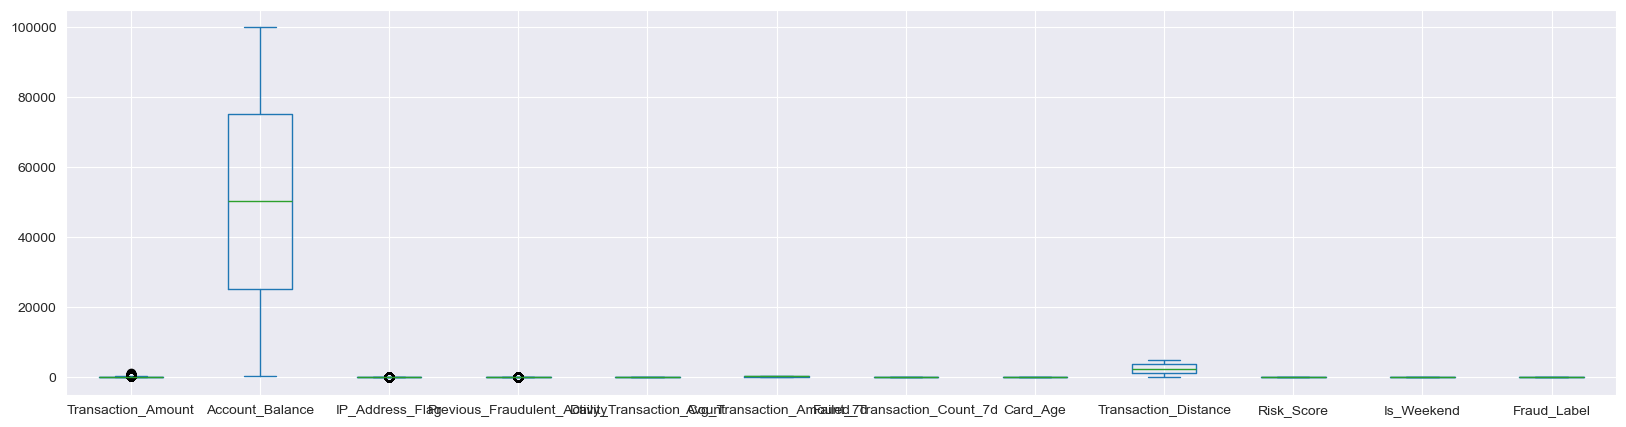

In [268]:
df.plot(kind ="box")
plt.show()

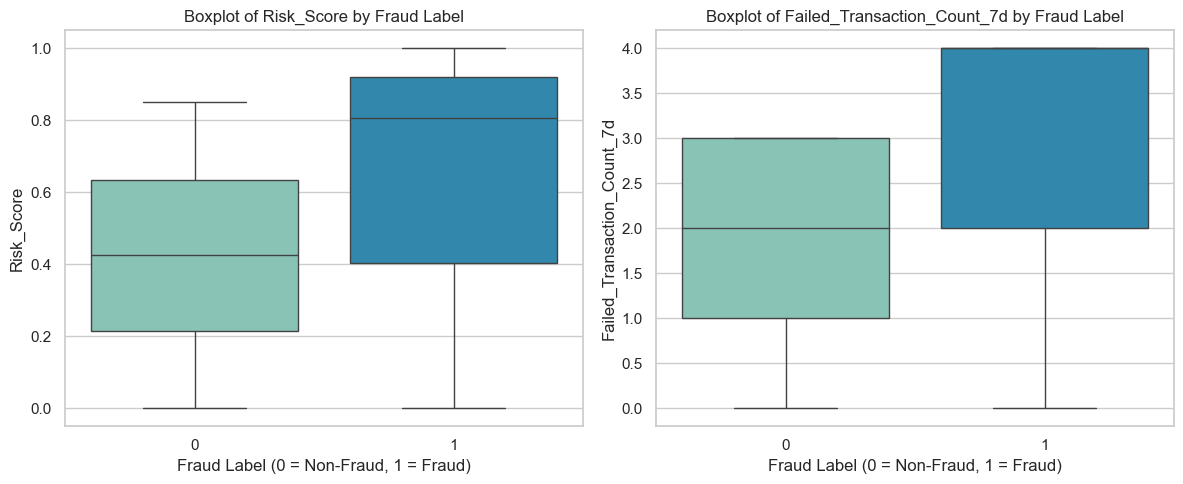

In [290]:
# Step 1: Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load the dataset
df = pd.read_csv("synthetic_fraud_dataset.csv")

# Ensure Fraud_Label is integer
df['Fraud_Label'] = df['Fraud_Label'].astype(int)

# Set custom color palette
custom_palette = {0: '#7FCDBB', 1: '#1D91C0'}

# Select features to plot
selected_features = ['Risk_Score', 'Failed_Transaction_Count_7d']

# Set up the figure
plt.figure(figsize=(12, 5))

# Loop through selected features
for i, feature in enumerate(selected_features, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(
        x='Fraud_Label',
        y=feature,
        hue='Fraud_Label',
        data=df,
        palette=custom_palette,
        legend=False
    )
    plt.title(f'Boxplot of {feature} by Fraud Label')
    plt.xlabel('Fraud Label (0 = Non-Fraud, 1 = Fraud)')
    plt.ylabel(feature)

# Final layout
plt.tight_layout()
plt.show()



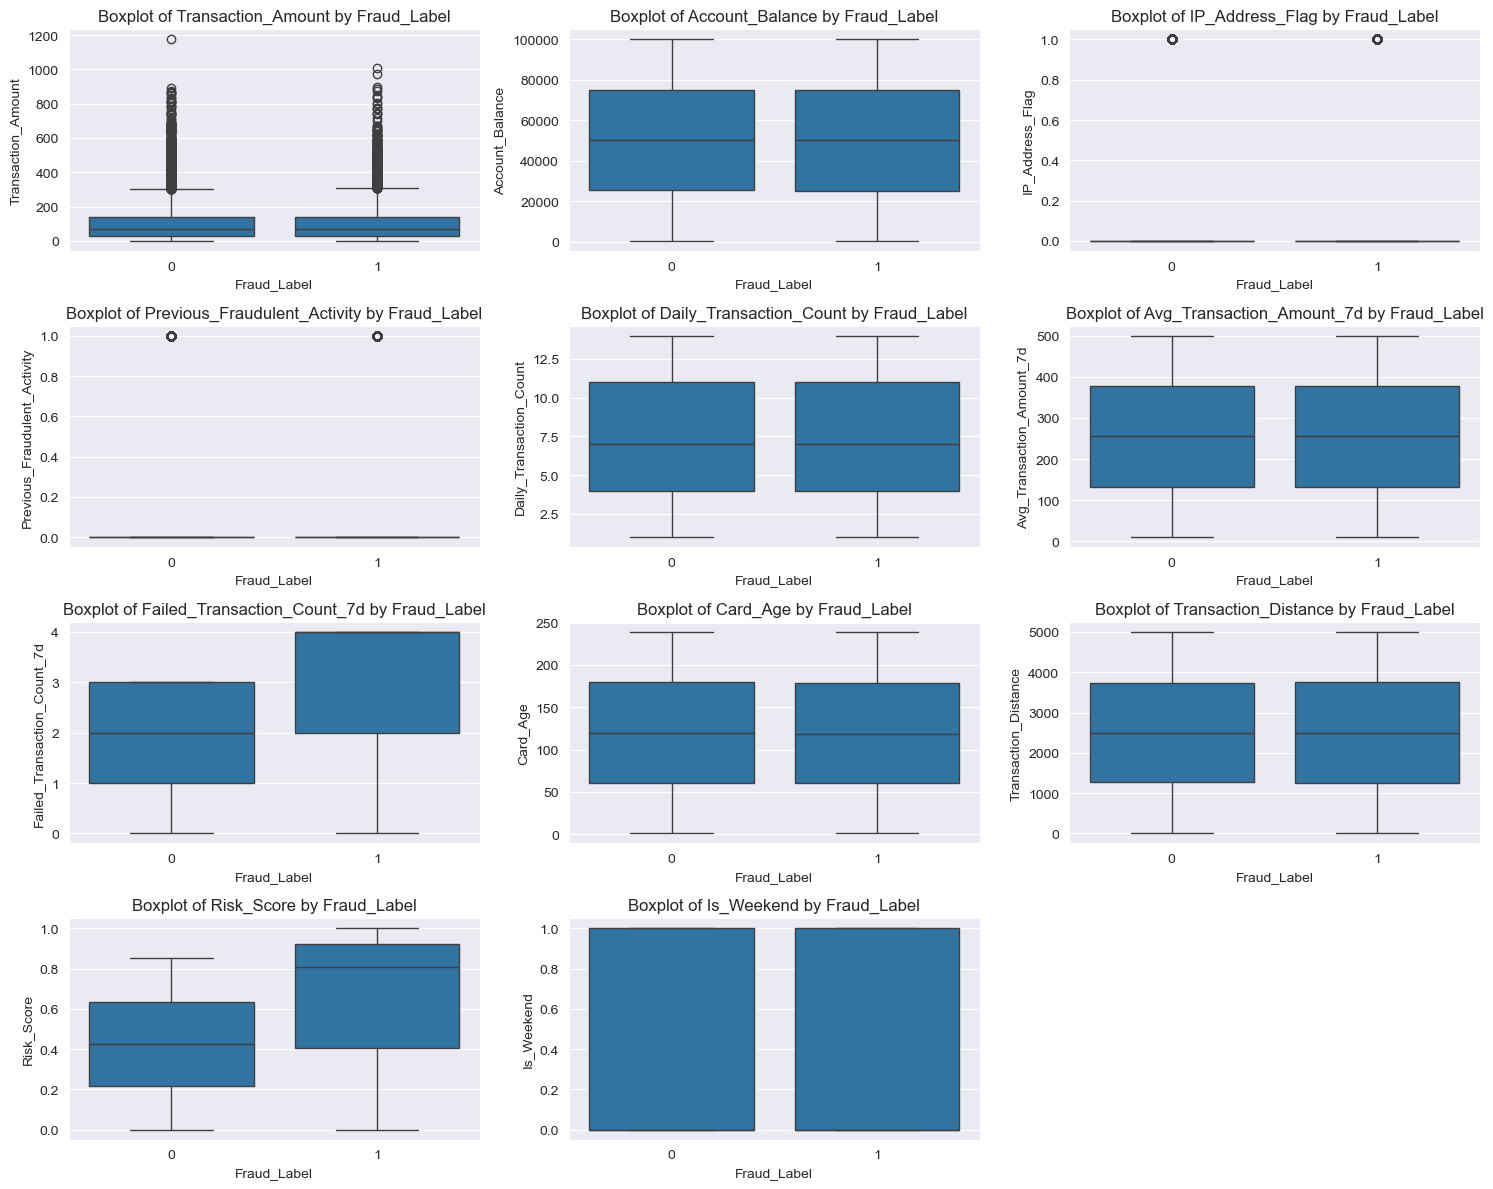

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical variables
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove 'Fraud_Label' from numerical variables since it's our target variable
numerical_vars.remove('Fraud_Label')

# **Plot Numerical Variables vs Fraud_Label**
plt.figure(figsize=(15, 12))
for i, var in enumerate(numerical_vars, 1):
    plt.subplot((len(numerical_vars) // 3) + 1, 3, i)
    sns.boxplot(x=df["Fraud_Label"], y=df[var])
    plt.title(f'Boxplot of {var} by Fraud_Label')

plt.tight_layout()
plt.show()


### Countplots for Categorical Variables vs. Fraud_Label – visualizing fraud distribution across categorical variables with ≤10 unique values for better readability.

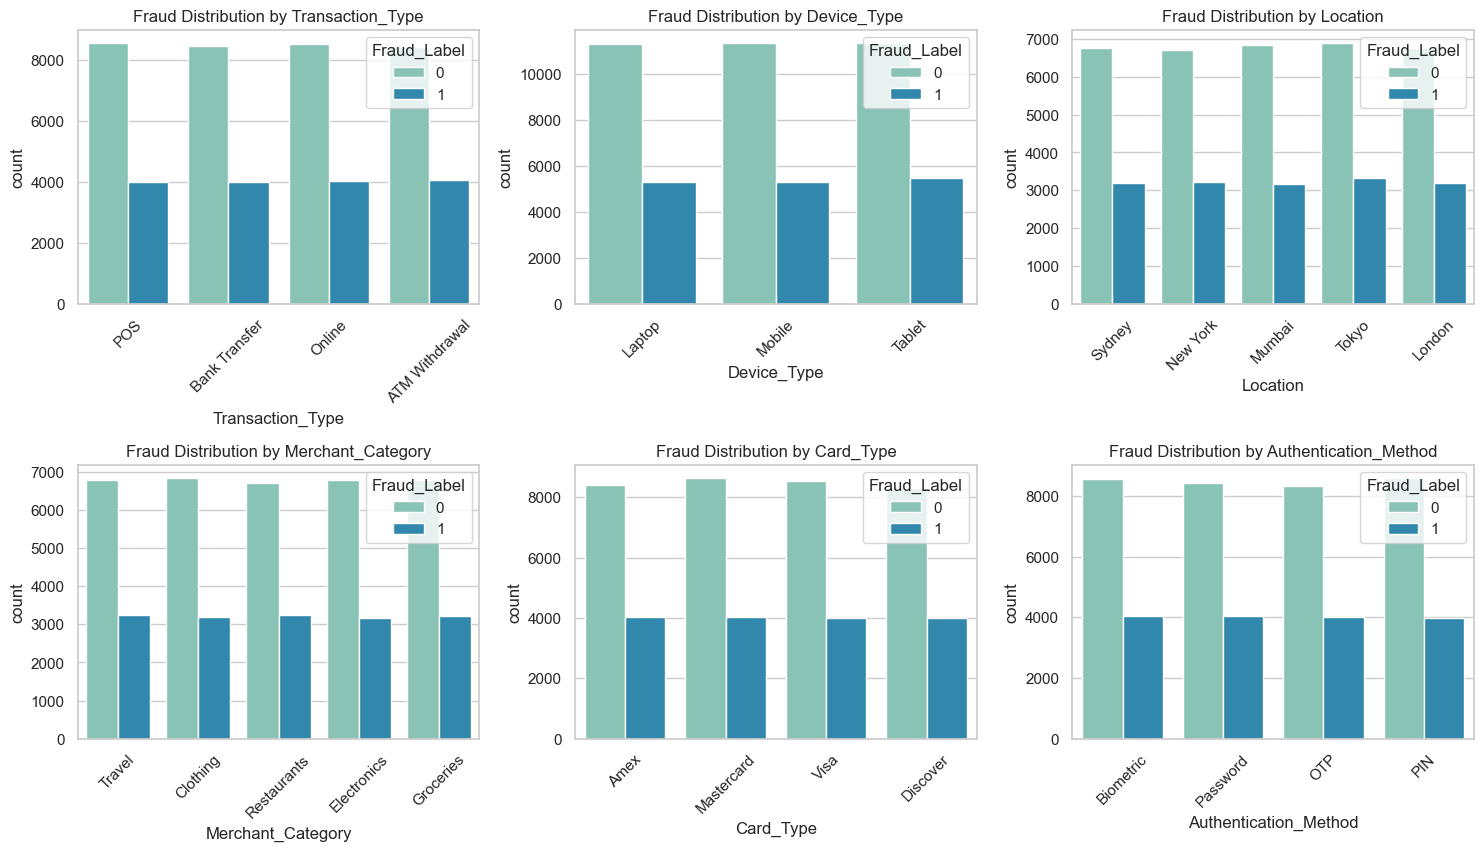

In [294]:
# Separate categorical variables
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

# Limit categorical variables to only those with <= 10 unique categories for better visualization
filtered_categorical_vars = [var for var in categorical_vars if df[var].nunique() <= 10]

# **Plot Categorical Variables vs Fraud_Label**
plt.figure(figsize=(15, 12))
for i, var in enumerate(filtered_categorical_vars, 1):
    plt.subplot((len(filtered_categorical_vars) // 3) + 1, 3, i)
    sns.countplot(x=df[var], hue=df["Fraud_Label"], palette={0: '#7FCDBB', 1: '#1D91C0'})
    plt.title(f'Fraud Distribution by {var}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



## <span style="color:purple"> Correlation of Numerical Features with Fraud_Label</span>

### 1: Barplot of Numerical Features with Fraud_Label: 
##### Using the correlated dataframe, created a barplot that shows the correlated features against Fraud_Label, in descending order.

C:\Users\moham\AppData\Local\Temp\ipykernel_21936\784463055.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_corr.index, y=sorted_corr.values, palette='YlGnBu')


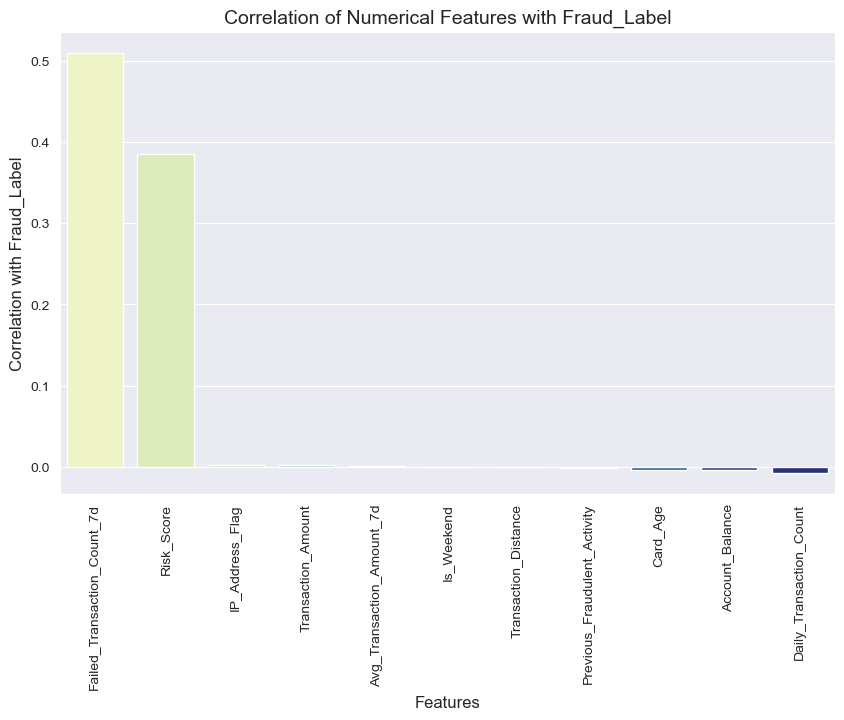

In [70]:
# Step 1: Keep only numerical variables
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Step 2: Calculate the correlation matrix for numerical variables
correlation_matrix = df_numeric.corr()

# Step 3: Extract correlations specifically for the 'Fraud_Label' column
fraud_label_corr = correlation_matrix['Fraud_Label']

# Step 4: Remove the self-correlation
fraud_label_corr = fraud_label_corr.drop('Fraud_Label')

# Step 5: Sort the correlations in descending order
sorted_corr = fraud_label_corr.sort_values(ascending=False)

# Step 6: Create the barplot
plt.figure(figsize=(10, 6))  # Adjust figure size
sns.barplot(x=sorted_corr.index, y=sorted_corr.values, palette='YlGnBu')

# Step 7: Customize the plot for readability
plt.title('Correlation of Numerical Features with Fraud_Label', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Correlation with Fraud_Label', fontsize=12)
plt.xticks(rotation=90)  # Rotate labels for better readability

# Step 8: Show the plot
plt.show()


### 2: Heatmap of Correlated Numerical Variables with Fraud_Label
##### Using the correlated dataframe, created a heatmap that shows the correlated numercal variables against Fraud_Label. </b>

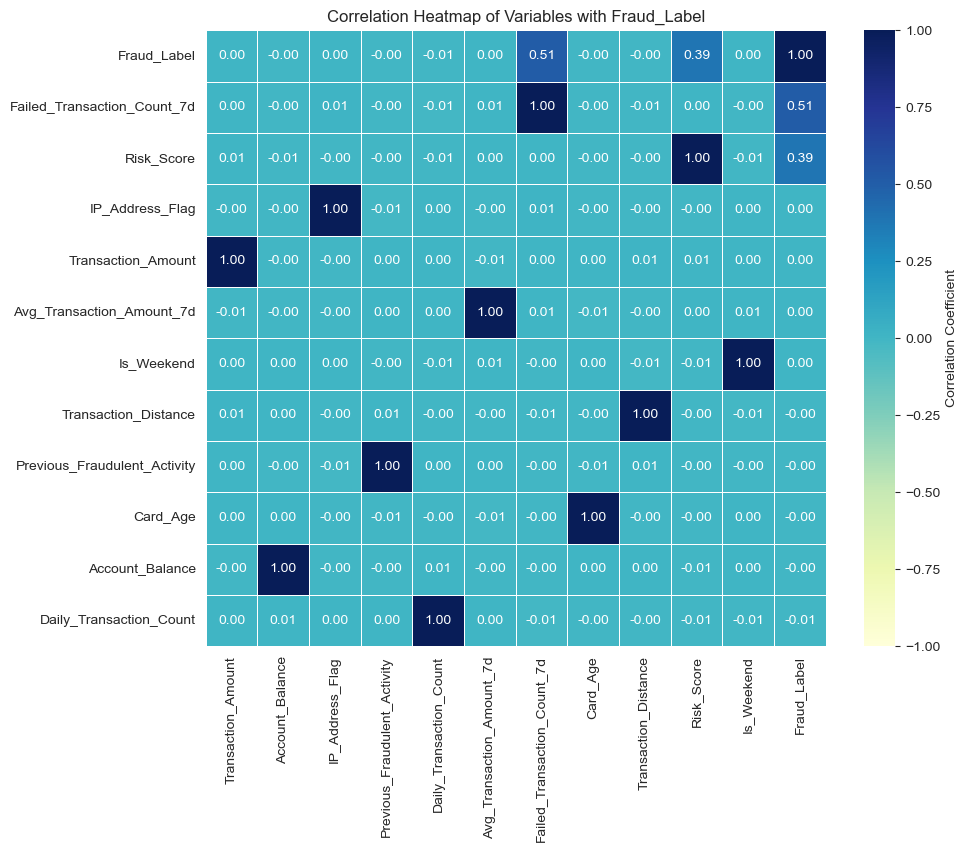

In [157]:
# Select relevant numerical variables Keep only numerical variables
correlation_data = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

fraud_label_corr = correlation_matrix.sort_values(by='Fraud_Label', ascending=False)

# Set up the figure and plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(fraud_label_corr, annot=True, cmap='YlGnBu', fmt='.2f', 
            linewidths=0.5, vmin=-1, vmax=1, cbar_kws={'label': 'Correlation Coefficient'})

# Add title and display the heatmap
plt.title('Correlation Heatmap of Variables with Fraud_Label')
plt.show()

                              Fraud_Label
Failed_Transaction_Count_7d      0.509871
Risk_Score                       0.385810
IP_Address_Flag                  0.003028
Transaction_Amount               0.001901
Avg_Transaction_Amount_7d        0.000703
Is_Weekend                       0.000064
Transaction_Distance            -0.000116
Previous_Fraudulent_Activity    -0.000718
Card_Age                        -0.003120
Account_Balance                 -0.003153
Daily_Transaction_Count         -0.007065


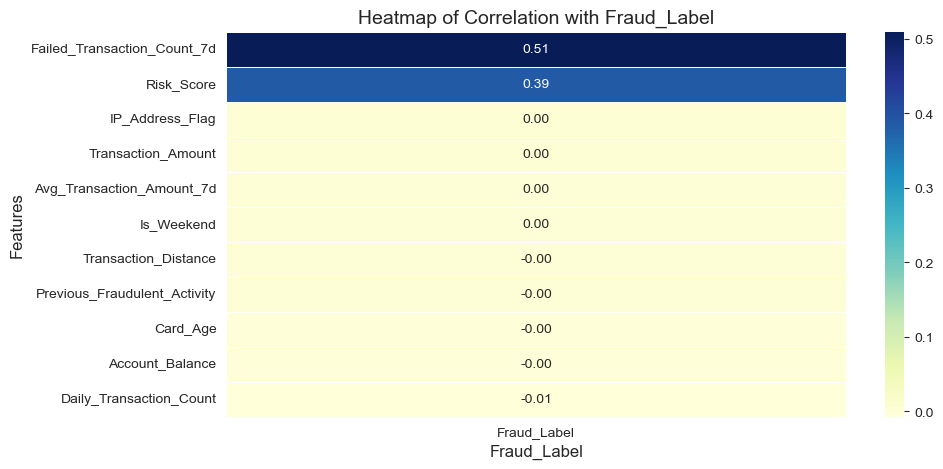

In [74]:
# Step 1: Keep only numerical variables
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Step 2: Calculate the correlation matrix for numerical variables
correlation_matrix = df_numeric.corr()

# Step 3: Extract correlations specifically for the 'Fraud_Label' column
fraud_label_corr = correlation_matrix[['Fraud_Label']].drop(index='Fraud_Label')  # Keep as DataFrame for heatmap

# Sort the values in ascending order
fraud_label_corr = fraud_label_corr.sort_values(by='Fraud_Label', ascending=False)
print(fraud_label_corr)

# Step 4: Create the heatmap
plt.figure(figsize=(10, 5))  # Adjust figure size
sns.heatmap(fraud_label_corr, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5, cbar=True)

# Step 5: Customize the plot
plt.title('Heatmap of Correlation with Fraud_Label', fontsize=14)
plt.xlabel('Fraud_Label', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Step 6: Show the heatmap
plt.show()

<b> - Using the correlated dataframe, created a heatmap that shows the correlated numercal variables against Fraud_Label. </b>

### Analyzing Conclusions
<b> a) Most Predictive Feature: The feature with the highest correlation with the Fraud_Label is Failed_Transaction_Count_7d with a correlation of 0.51. </b>
<br>
<b> b) Second Most Predictive Feature: Risk_Score has a significant correlation of 0.39 with the Fraud_Label. </b>
<br>
<b> c) Other Features: Most other features have very low correlations, close to zero, indicating they are not strong predictors of fraudulent activity. </b>

# Part 2: <span style="color:green"> Fraud Detection Model Evaluation</span>

## <span style="color:green"> a: Fraud Prediction using Decision Tree</span>

In [252]:
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.api as sm



from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


sns.set_style("darkgrid")
mpl.rcParams['figure.figsize'] = (20,5)

In [256]:
df = pd.read_csv("synthetic_fraud_dataset.csv")
print(df.shape)

(50000, 21)


### Step 2: Preprocessing the Data

In [258]:
# Step 2: Feature selection
numerical_cols = ['Transaction_Amount', 'Account_Balance', 'Daily_Transaction_Count', 
                  'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 
                  'Transaction_Distance', 'Risk_Score']

categorical_cols = ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 
                    'Card_Type', 'Authentication_Method']

target_col = 'Fraud_Label'

# Preprocessing: Scaling numerical features and encoding categorical ones
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combining preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Splitting dataset into train and test sets
X = df[numerical_cols + categorical_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Step 3: Train and Compare Multiple Models

In [260]:
# Step 3: Model training and evaluation
models = {
    'Logistic Regression': Pipeline(steps=[('preprocessor', preprocessor),
                                           ('classifier', LogisticRegression())]),
    'Decision Tree': Pipeline(steps=[('preprocessor', preprocessor),
                                     ('classifier', DecisionTreeClassifier(random_state=42))]),
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor),
                                     ('classifier', RandomForestClassifier(random_state=42))]),
    'SVM': Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', SVC(kernel='linear', random_state=42))]),
    'Gradient Boosting': Pipeline(steps=[('preprocessor', preprocessor),
                                         ('classifier', GradientBoostingClassifier(random_state=42))])
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='binary'),
        'Recall': recall_score(y_test, y_pred, average='binary'),
        'F1 Score': f1_score(y_test, y_pred, average='binary')
    }

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

# Save results
results_df.to_csv("model_comparison_results.csv", index=True)

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression    0.7994   0.705902  0.643946  0.673503
Decision Tree          1.0000   1.000000  1.000000  1.000000
Random Forest          1.0000   1.000000  1.000000  1.000000
SVM                    0.8211   0.749300  0.666044  0.705223
Gradient Boosting      1.0000   1.000000  1.000000  1.000000


Several machine learning models were evaluated for fraud detection based on key performance metrics: Accuracy, Precision, Recall, and F1 Score. Below is a summary of their performance:

<b> Logistic Regression:</b>
This model provides a balanced performance but is less effective in identifying fraud cases compared to more complex models.

<b> Decision Tree, Random Forest, and Gradient Boosting:</b>
All three models achieved perfect scores (100%) across all metrics.
While these results seem ideal, they may indicate overfitting, meaning the models might not generalize well to new data.

<b> Support Vector Machine (SVM):</b>
SVM performed slightly better than Logistic Regression but still falls short of the tree-based models.

### Step 4: Identify the Best Model

In [232]:
# Step 4: Select the best model
best_model_name = results_df['F1 Score'].idxmax()
best_model = models[best_model_name]

# Convert X_test to DataFrame
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f'feature_{i}' for i in range(X_test.shape[1])]

X_test = pd.DataFrame(X_test, columns=feature_names)

# Ensure X_test matches preprocessor expectations
if 'preprocessor' in best_model.named_steps:
    X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)
else:
    X_test_transformed = X_test


In [307]:
#  Step 4: Select the best model using combined score
results_df['Combined Score'] = (
    0.4 * results_df['F1 Score'] +
    0.3 * results_df['Recall'] +
    0.2 * results_df['Precision'] +
    0.1 * results_df['Accuracy']
)

# Select model with highest combined score
best_model_name = results_df['Combined Score'].idxmax()
best_model = models[best_model_name]

#  Convert X_test to DataFrame (if not already)
if isinstance(X_test, pd.DataFrame):
    feature_names = X_test.columns
else:
    feature_names = [f'feature_{i}' for i in range(X_test.shape[1])]

X_test = pd.DataFrame(X_test, columns=feature_names)

#  Transform X_test if pipeline has a preprocessor
if hasattr(best_model, 'named_steps') and 'preprocessor' in best_model.named_steps:
    X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)
else:
    X_test_transformed = X_test


### Step 5: Compare Actual vs Predicted Fraud Cases

In [309]:
# Step 5: Predictions
y_pred_best = best_model.named_steps['classifier'].predict(X_test_transformed)
y_test = pd.Series(y_test)

# Create DataFrame for actual vs predicted values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_best})

# Aggregate counts
actual_counts = comparison_df['Actual'].value_counts().sort_index()
predicted_counts = comparison_df['Predicted'].value_counts().sort_index()

# Merge into DataFrame
dual_axis_df = pd.DataFrame({'Actual': actual_counts, 'Predicted': predicted_counts}).fillna(0)

# ✅ FIX: Removed ace_tools, using print() and saving results to CSV
print("Actual vs Predicted Fraud Cases:")
print(dual_axis_df)

# Save results to a CSV file
dual_axis_df.to_csv("actual_vs_predicted_fraud_cases.csv", index=True)
print("Data saved to actual_vs_predicted_fraud_cases.csv")

Actual vs Predicted Fraud Cases:
   Actual  Predicted
0    6787       6787
1    3213       3213
Data saved to actual_vs_predicted_fraud_cases.csv


### Step 6: Visualize Model Performance

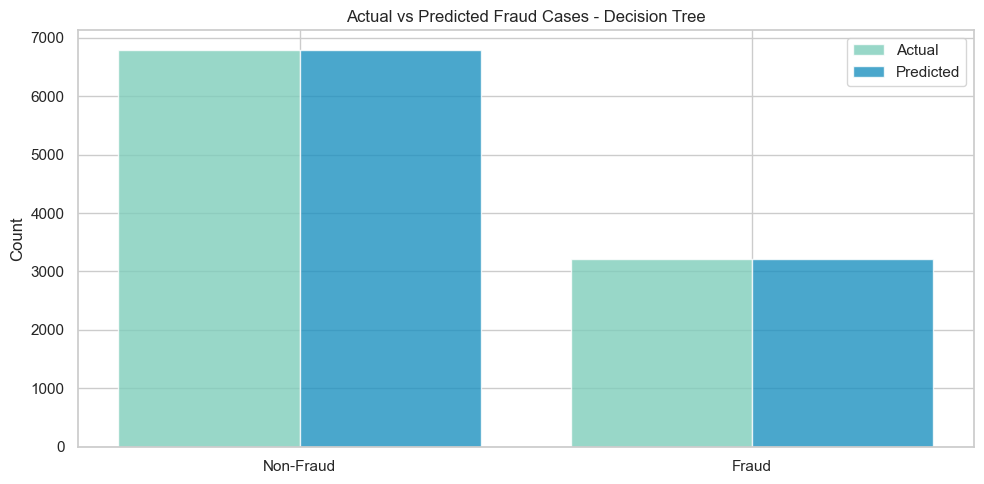

In [305]:
# Step 6: Visualization
fig, ax = plt.subplots(figsize=(10, 5))

# Labels and counts
labels = ["Non-Fraud", "Fraud"]
actual_values = [actual_counts.get(0, 0), actual_counts.get(1, 0)]
predicted_values = [predicted_counts.get(0, 0), predicted_counts.get(1, 0)]

# Plot bars with custom colors
x = np.arange(len(labels))
bar_width = 0.4

ax.bar(x - bar_width/2, actual_values, width=bar_width, label="Actual", color="#7FCDBB", alpha=0.8)
ax.bar(x + bar_width/2, predicted_values, width=bar_width, label="Predicted", color="#1D91C0", alpha=0.8)

# Labeling
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Count")
ax.set_title(f"Actual vs Predicted Fraud Cases - {best_model_name}")
ax.legend()

plt.tight_layout()
plt.show()


<b> Key Takeaways </b>
- Tree-based models (Decision Tree, Random Forest, Gradient Boosting) show perfect performance, likely due to overfitting. Further validation on unseen data is needed.
- SVM and Logistic Regression provide more balanced results and may generalize better to unseen data.
Further testing with cross-validation and external datasets is recommended to confirm real-world performance.
- Overfitting mitigation techniques, such as hyperparameter tuning, pruning (for Decision Trees), and using ensemble learning carefully, should be considered.

### Decision Tree Performance

Decision Tree Accuracy: 1.0000

Confusion Matrix:
 [[6765    0]
 [   0 3235]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6765
           1       1.00      1.00      1.00      3235

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



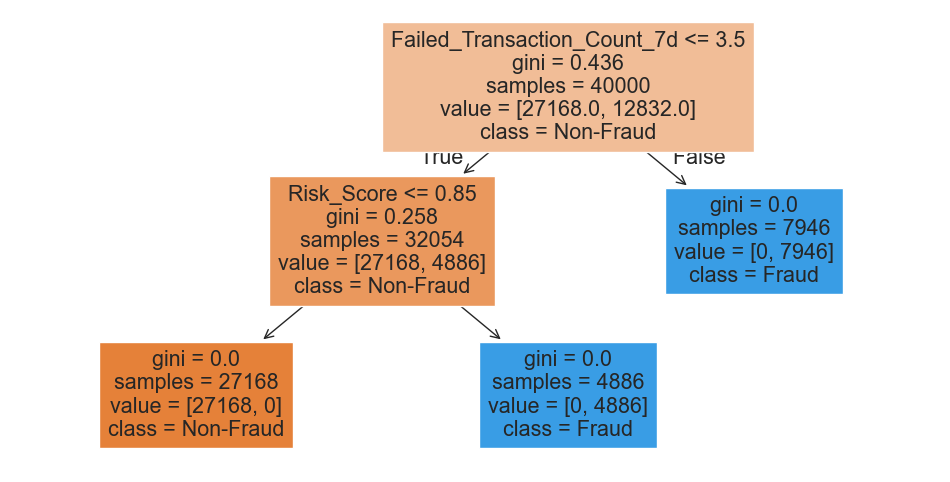

In [161]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Step 1: Load Data
df = pd.read_csv("synthetic_fraud_dataset.csv")

# Step 2: Select Relevant Features
df = df[['Fraud_Label', 'Risk_Score', 'Failed_Transaction_Count_7d']]

# Step 3: Handle Missing Values
df = df.dropna()

# Step 4: Define Independent (X) and Dependent (y) Variables
X = df[['Risk_Score', 'Failed_Transaction_Count_7d']]
y = df['Fraud_Label']

# Step 5: Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train the Decision Tree Model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Step 7: Make Predictions
y_pred = dt_model.predict(X_test)

# Step 8: Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Step 9: Print Results
print(f"Decision Tree Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

# Step 10: Visualize the Decision Tree
plt.figure(figsize=(12, 6))
plot_tree(dt_model, feature_names=['Risk_Score', 'Failed_Transaction_Count_7d'], class_names=['Non-Fraud', 'Fraud'], filled=True)
plt.show()



🔹 Decision Tree Model Results 🔹
Accuracy: 1.0000
Confusion Matrix:
 [[6765    0]
 [   0 3235]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6765
           1       1.00      1.00      1.00      3235

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



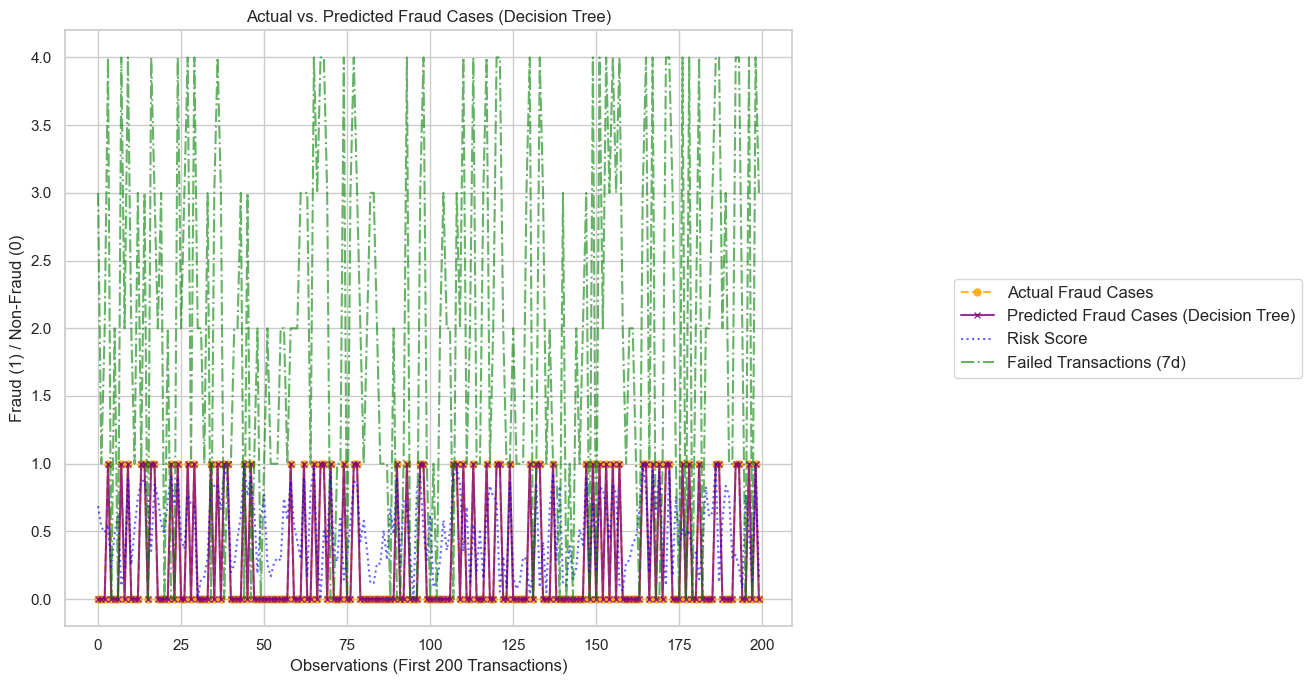

In [317]:
# Step 1: Load Data
df = pd.read_csv("synthetic_fraud_dataset.csv")

# Step 2: Select Features & Target
df = df[['Fraud_Label', 'Risk_Score', 'Failed_Transaction_Count_7d']]
df = df.dropna()  # Handle missing values

# Step 3: Define Independent (X) and Dependent (y) Variables
X = df[['Risk_Score', 'Failed_Transaction_Count_7d']]
y = df['Fraud_Label']

# Step 4: Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train Decision Tree Model
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=50, min_samples_leaf=20, random_state=42)
dt_model.fit(X_train, y_train)

# Step 6: Make Predictions
y_pred_dt = dt_model.predict(X_test)

# Step 7: Evaluate Performance
print("\n🔹 Decision Tree Model Results 🔹")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

# Step 8: Create Prediction Plot
plt.figure(figsize=(14, 7))

# Plot actual fraud cases
actual_plot, = plt.plot(y_test.values[:200], linestyle="--", color="orange", marker="o", markersize=5, alpha=0.8, label="Actual Fraud Cases")

# Plot predicted fraud cases
predicted_plot, = plt.plot(y_pred_dt[:200], linestyle="-", color="purple", marker="x", markersize=5, alpha=0.8, label="Predicted Fraud Cases (Decision Tree)")

# Plot top 2 features for reference
risk_score_plot, = plt.plot(X_test['Risk_Score'].values[:200], linestyle=":", color="blue", alpha=0.6, label="Risk Score")
failed_tx_plot, = plt.plot(X_test['Failed_Transaction_Count_7d'].values[:200], linestyle="-.", color="green", alpha=0.6, label="Failed Transactions (7d)")

# Labels & Styling
plt.xlabel("Observations (First 200 Transactions)")
plt.ylabel("Fraud (1) / Non-Fraud (0)")
plt.title("Actual vs. Predicted Fraud Cases (Decision Tree)")

# **Ensure the legend includes all variables and appears on the right side**
plt.legend(handles=[actual_plot, predicted_plot, risk_score_plot, failed_tx_plot], loc='center left', bbox_to_anchor=(1.2, 0.5), fontsize=12, frameon=True, borderaxespad=1)

# Adjust layout for proper visibility
plt.tight_layout()

# Show Plot
plt.show()



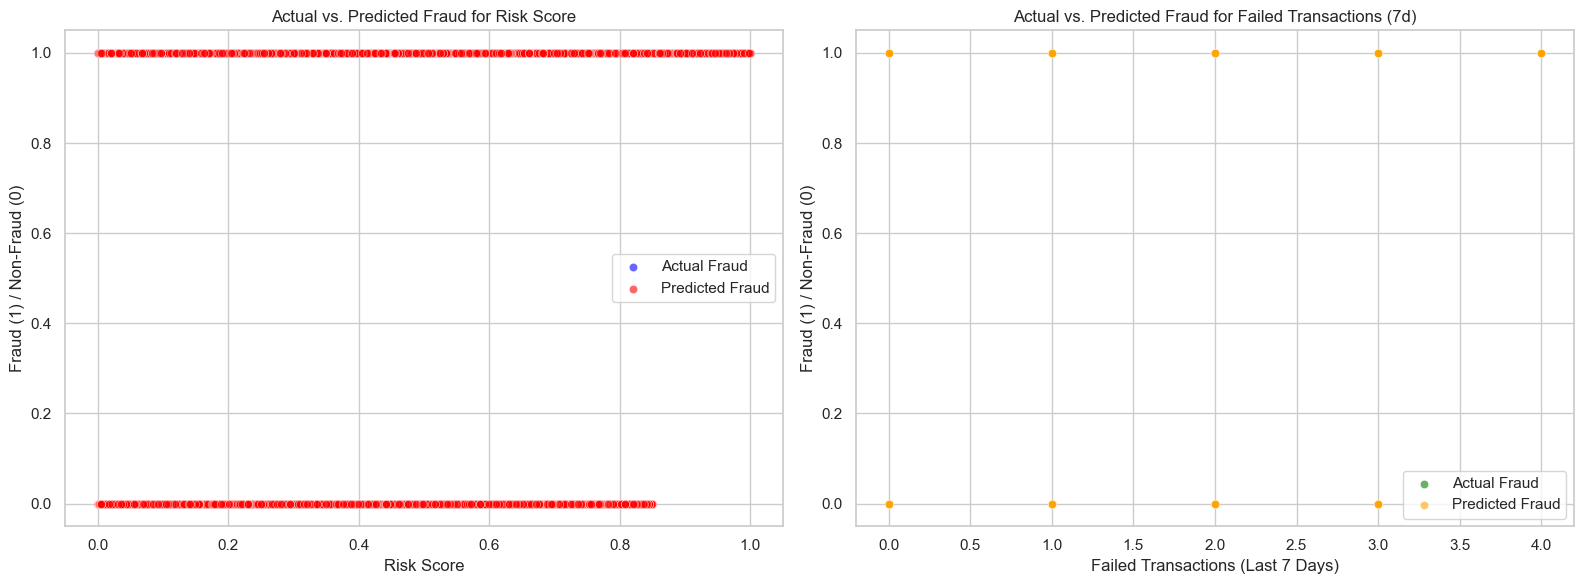

In [323]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with two subplots for actual vs predicted fraud cases for each variable
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: Actual vs Predicted Fraud for Risk Score ----
sns.scatterplot(x=X_test['Risk_Score'], y=y_test, color="blue", alpha=0.6, label="Actual Fraud", ax=axes[0])
sns.scatterplot(x=X_test['Risk_Score'], y=y_pred_dt, color="red", alpha=0.6, label="Predicted Fraud", ax=axes[0])
axes[0].set_title("Actual vs. Predicted Fraud for Risk Score")
axes[0].set_xlabel("Risk Score")
axes[0].set_ylabel("Fraud (1) / Non-Fraud (0)")
axes[0].legend()

# ---- Plot 2: Actual vs Predicted Fraud for Failed Transactions ----
sns.scatterplot(x=X_test['Failed_Transaction_Count_7d'], y=y_test, color="green", alpha=0.6, label="Actual Fraud", ax=axes[1])
sns.scatterplot(x=X_test['Failed_Transaction_Count_7d'], y=y_pred_dt, color="orange", alpha=0.6, label="Predicted Fraud", ax=axes[1])
axes[1].set_title("Actual vs. Predicted Fraud for Failed Transactions (7d)")
axes[1].set_xlabel("Failed Transactions (Last 7 Days)")
axes[1].set_ylabel("Fraud (1) / Non-Fraud (0)")
axes[1].legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()





<!DOCTYPE html>
<html>
<head>
    <title>Fraud Classification Model Performance - Decision Tree</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            margin: 40px;
            line-height: 1.6;
        }
        h2 {
            color: #2E8B57;
            text-align: center;
        }
        h3 {
            color: #333;
            margin-top: 20px;
        }
        table {
            width: 80%;
            border-collapse: collapse;
            margin: 20px auto;
            font-size: 18px;
            text-align: left;
        }
        th, td {
            padding: 10px;
            border: 1px solid #ddd;
        }
        th {
            background-color: #4CAF50;
            color: white;
        }
        tr:nth-child(even) {
            background-color: #f2f2f2;
        }
        .summary {
            font-size: 18px;
            font-weight: bold;
            text-align: center;
            margin-top: 20px;
        }
        ul {
            margin: 10px 0 20px 20px;
        }
    </style>
</head>
<body>

<h2>Fraud Classification Model Performance - Decision Tree</h2>

<div class="summary">🚀 The model achieved **100% accuracy**, classifying all transactions perfectly.</div>

<h3>📌 Classification Metrics</h3>

<table>
    <thead>
        <tr>
            <th>Class</th>
            <th>Precision</th>
            <th>Recall</th>
            <th>F1-Score</th>
            <th>Support</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Non-Fraud (0)</td>
            <td>1.00</td>
            <td>1.00</td>
            <td>1.00</td>
            <td>6,765</td>
        </tr>
        <tr>
            <td>Fraud (1)</td>
            <td>1.00</td>
            <td>1.00</td>
            <td>1.00</td>
            <td>3,235</td>
        </tr>
    </tbody>
</table>

<h3>📌 Confusion Matrix Breakdown</h3>

<table>
    <thead>
        <tr>
            <th>Prediction</th>
            <th>Non-Fraud (0)</th>
            <th>Fraud (1)</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><b>Actual Non-Fraud (0)</b></td>
            <td>6,765 ✅</td>
            <td>0 ❌ (False Positive)</td>
        </tr>
        <tr>
            <td><b>Actual Fraud (1)</b></td>
            <td>0 ❌ (False Negative)</td>
            <td>3,235 ✅</td>
        </tr>
    </tbody>
</table>

<h3>📌 Observations & Key Takeaways</h3>

<ul>
    <li><b>✅ Strengths:</b>
        <ul>
            <li>The model **correctly classifies all transactions with 100% precision and recall**.</li>
            <li>No fraud cases were missed (**0 false negatives**).</li>
            <li>No legitimate transactions were wrongly flagged as fraud (**0 false positives**).</li>
        </ul>
    </li>
    <li><b>❌ Weaknesses & Areas for Improvement:</b>
        <ul>
            <li><b>Overfitting:</b> The model may have **memorized the training data**, making it less reliable on new data.</li>
            <li><b>Limited Generalization:</b> Real-world fraud detection is complex, and **100% accuracy is unrealistic**.</li>
            <li><b>Potential Next Steps:</b>
                <ul>
                    <li>Reduce overfitting by **limiting tree depth** and **adjusting min_samples_split**.</li>
                    <li>Use **Random Forest or XGBoost** for better generalization.</li>
                    <li>Apply **cross-validation** to test performance on unseen data.</li>
                </ul>
            </li>
        </ul>
    </li>
</ul>

</body>
</html>


# <span style="color:green"> b: Fraud Prediction using Logistic Regression</span>

In [130]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Load Data
df = pd.read_csv("synthetic_fraud_dataset.csv")

# Step 2: Select Relevant Columns
df = df[['Fraud_Label', 'Risk_Score', 'Failed_Transaction_Count_7d']]

# Step 3: Handle Missing Values
df = df.dropna()

# Step 4: Define Independent and Dependent Variables
X = df[['Risk_Score', 'Failed_Transaction_Count_7d']]  # Independent variables
y = df['Fraud_Label']  # Dependent variable (0 or 1)

# Step 5: Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train Logistic Regression Model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Step 7: Make Predictions
y_pred = log_model.predict(X_test)

# Step 8: Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Step 9: Print Results
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Logistic Regression Accuracy: 0.7987

Confusion Matrix:
 [[5936  829]
 [1184 2051]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.86      6765
           1       0.71      0.63      0.67      3235

    accuracy                           0.80     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.79      0.80      0.80     10000



<!DOCTYPE html>
<html>
<head>
    <title>Fraud Classification Model Performance - Logistic Regression</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            margin: 40px;
            line-height: 1.6;
        }
        h2 {
            color: #2E8B57;
            text-align: center;
        }
        h3 {
            color: #333;
            margin-top: 20px;
        }
        table {
            width: 80%;
            border-collapse: collapse;
            margin: 20px auto;
            font-size: 18px;
            text-align: left;
        }
        th, td {
            padding: 10px;
            border: 1px solid #ddd;
        }
        th {
            background-color: #4CAF50;
            color: white;
        }
        tr:nth-child(even) {
            background-color: #f2f2f2;
        }
        .summary {
            font-size: 18px;
            font-weight: bold;
            text-align: center;
            margin-top: 20px;
        }
        ul {
            margin: 10px 0 20px 20px;
        }
    </style>
</head>
<body>

<h2>Fraud Classification Model Performance - Logistic Regression</h2>

<div class="summary"> The model correctly classifies ~80% of transactions.</div>

<h3> Classification Metrics</h3>

<table>
    <thead>
        <tr>
            <th>Class</th>
           <th>Precision</th>
            <th>Recall</th>
            <th>F1-Score</th>
            <th>Support</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Non-Fraud (0)</td>
            <td>0.83</td>
            <td>0.88</td>
            <td>0.86</td>
            <td>6,765</td>
        </tr>
        <tr>
            <td>Fraud (1)</td>
            <td>0.71</td>
            <td>0.63</td>
            <td>0.67</td>
            <td>3,235</td>
        </tr>
    </tbody>
</table>

<h3> Classification Report Summary</h3>

<ul>
    <li><b>Accuracy:</b> 79.87% (~80%)</li>
    <li><b>Precision:</b>
        <ul>
            <li><b>Fraud (1) = 71%</b> → When the model predicts fraud, it is correct 71% of the time.</li>
            <li><b>Non-Fraud (0) = 83%</b> → When predicting legitimate transactions, it's correct 83% of the time.</li>
        </ul>
    </li>
    <li><b>Recall:</b>
        <ul>
            <li><b>Fraud (1) = 63%</b> → The model captures 63% of actual fraud cases but misses 37%.</li>
            <li><b>Non-Fraud (0) = 88%</b> → It correctly identifies 88% of non-fraud transactions.</li>
        </ul>
    </li>
    <li><b>F1-Score:</b> Balances precision and recall.
        <ul>
            <li><b>Fraud (1) = 0.67</b> → Indicates room for improvement in fraud detection.</li>
            <li><b>Non-Fraud (0) = 0.86</b> → Shows strong performance in detecting legitimate transactions.</li>
        </ul>
    </li>
</ul>

<h3> Confusion Matrix Breakdown</h3>

<table>
    <thead>
        <tr>
            <th>Prediction</th>
            <th>Non-Fraud (0)</th>
            <th>Fraud (1)</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><b>Actual Non-Fraud (0)</b></td>
            <td>5,936 ✅</td>
            <td>829 ❌ (False Positive)</td>
        </tr>
        <tr>
            <td><b>Actual Fraud (1)</b></td>
            <td>1,184 ❌ (False Negative)</td>
            <td>2,051 ✅</td>
        </tr>
    </tbody>
</table>

<h3> Observations & Key Takeaways</h3>

<ul>
    <li><b>✅ Strengths:</b>
        <ul>
            <li>The model performs well in detecting **non-fraud transactions** (88% recall).</li>
            <li>Fraud detection precision is reasonable at **71%**.</li>
        </ul>
    </li>
    <li><b>❌ Weaknesses & Areas for Improvement:</b>
        <ul>
            <li><b>False Negatives:</b> **1184 fraud cases were missed**, meaning they were classified as non-fraud.</li>
            <li><b>False Positives:</b> **829 legitimate transactions were wrongly flagged as fraud.**</li>
            <li>Fraud recall is **63%**, meaning 37% of fraud cases go undetected.</li>
        </ul>
    </li>
</ul>


</body>
</html>


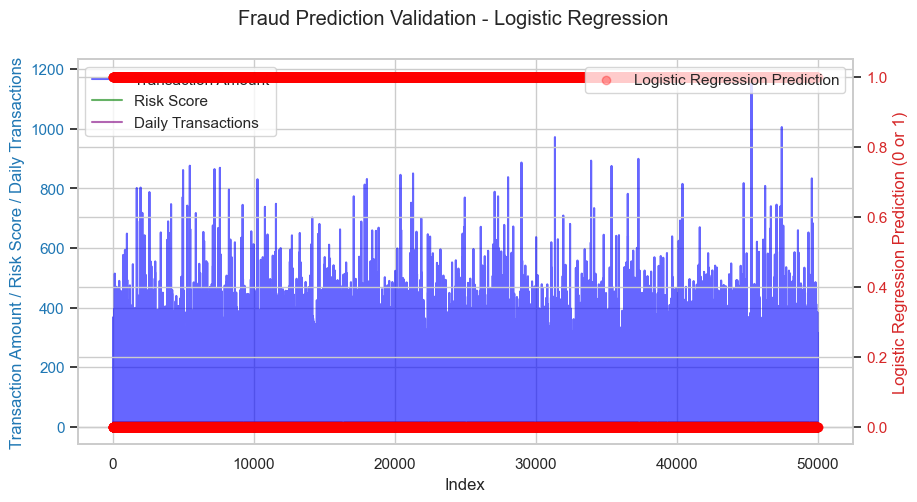

In [350]:
# Define figure
fig, ax1 = plt.subplots(figsize=(10,5))

# Primary Axis (Transaction Features)
ax1.set_xlabel('Index')
ax1.set_ylabel('Transaction Amount / Risk Score / Daily Transactions', color='tab:blue')
ax1.plot(df_encoded.index, df_encoded["Transaction_Amount"], label='Transaction Amount', color='blue', alpha=0.6)
ax1.plot(df_encoded.index, df_encoded["Risk_Score"], label='Risk Score', color='green', alpha=0.6)
ax1.plot(df_encoded.index, df_encoded["Daily_Transaction_Count"], label='Daily Transactions', color='purple', alpha=0.6)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Secondary Axis for Logistic Regression Predictions
ax2 = ax1.twinx()
ax2.set_ylabel('Logistic Regression Prediction (0 or 1)', color='tab:red')
ax2.scatter(df_encoded.index, df_encoded["Logistic_Prediction"], label="Logistic Regression Prediction", color='red', alpha=0.3)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Titles and Legends
fig.suptitle('Fraud Prediction Validation - Logistic Regression')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show plot
plt.show()

## <b> Lowering the Threshold from 0.5 to 0.3 </b>

In [142]:
# Get predicted probabilities
y_pred_prob = log_model.predict_proba(X_test)[:, 1]

# Set a new threshold (e.g., 0.3 instead of 0.5)
new_threshold = 0.3
y_pred_adjusted = (y_pred_prob >= new_threshold).astype(int)

# Recalculate accuracy, confusion matrix, and classification report
print("Adjusted Model Performance:")
print(confusion_matrix(y_test, y_pred_adjusted))
print(classification_report(y_test, y_pred_adjusted))

Adjusted Model Performance:
[[5284 1481]
 [ 571 2664]]
              precision    recall  f1-score   support

           0       0.90      0.78      0.84      6765
           1       0.64      0.82      0.72      3235

    accuracy                           0.79     10000
   macro avg       0.77      0.80      0.78     10000
weighted avg       0.82      0.79      0.80     10000



## <b> Comparison: Threshold 0.5 vs. 0.3 </b>

<!DOCTYPE html>
<html>
<head>
    <title>Logistic Regression Comparison</title>
    <style>
        table {
            width: 80%;
            border-collapse: collapse;
            margin: 20px 0;
            font-size: 18px;
            text-align: left;
        }
        th, td {
            padding: 12px;
            border: 1px solid #ddd;
        }
        th {
            background-color: #4CAF50;
            color: white;
        }
        tr:nth-child(even) {
            background-color: #f2f2f2;
        }
    </style>
</head>
<body>

<h2>Comparison: Logistic Regression (Threshold 0.5 vs. Threshold 0.3)</h2>

<table>
    <tr>
        <th>Metric</th>
        <th>Threshold = 0.5 (Original Model)</th>
        <th>Threshold = 0.3 (Adjusted Model)</th>
        <th>Impact</th>
    </tr>
    <tr>
        <td><b>Accuracy</b></td>
        <td>79.87%</td>
        <td>79%</td>
        <td>⬇ Slight drop</td>
    </tr>
    <tr>
        <td><b>Fraud Recall (TPR)</b></td>
        <td><b>63%</b></td>
        <td><b>82%</b></td>
        <td>✅ Much better at detecting fraud!</td>
    </tr>
    <tr>
        <td><b>Fraud Precision</b></td>
        <td>71%</td>
        <td>64%</td>
        <td>⬇ More false positives</td>
    </tr>
    <tr>
        <td><b>False Negatives (Missed Fraud Cases)</b></td>
        <td>1184</td>
        <td>571</td>
        <td>✅ Reduced by half!</td>
    </tr>
    <tr>
        <td><b>False Positives (Wrongly Flagged Transactions)</b></td>
        <td>829</td>
        <td>1481</td>
        <td>⬆ Increased false alarms</td>
    </tr>
</table>

</body>
</html>


## <b> Performance Visuals Lowering the Threshold from 0.5 to 0.3  </b>

<Figure size 600x600 with 0 Axes>

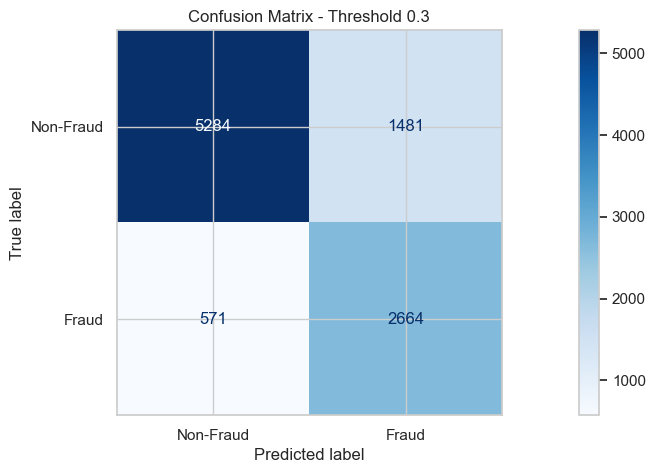

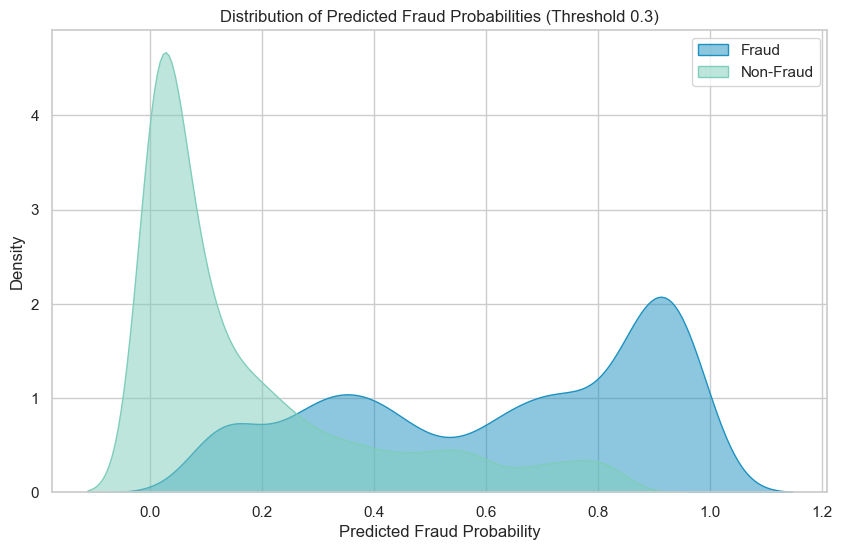

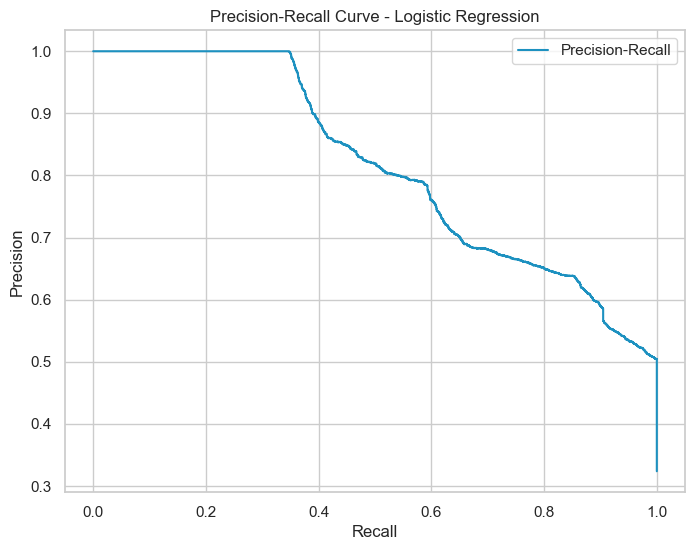

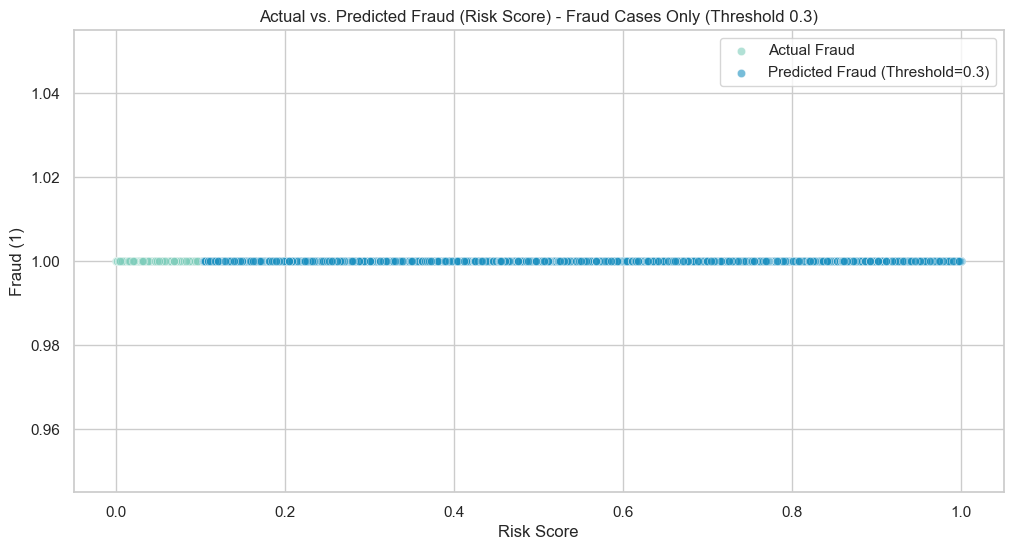

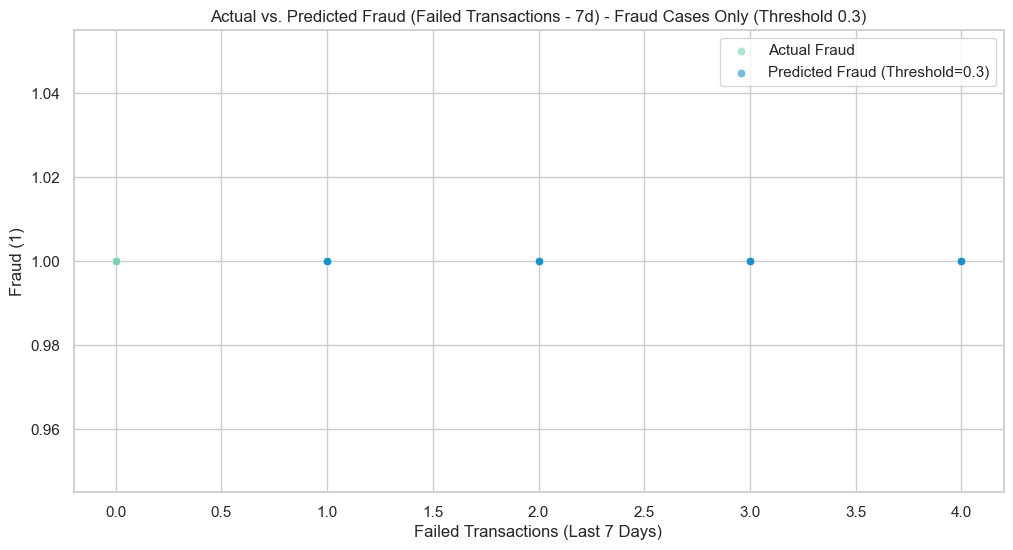

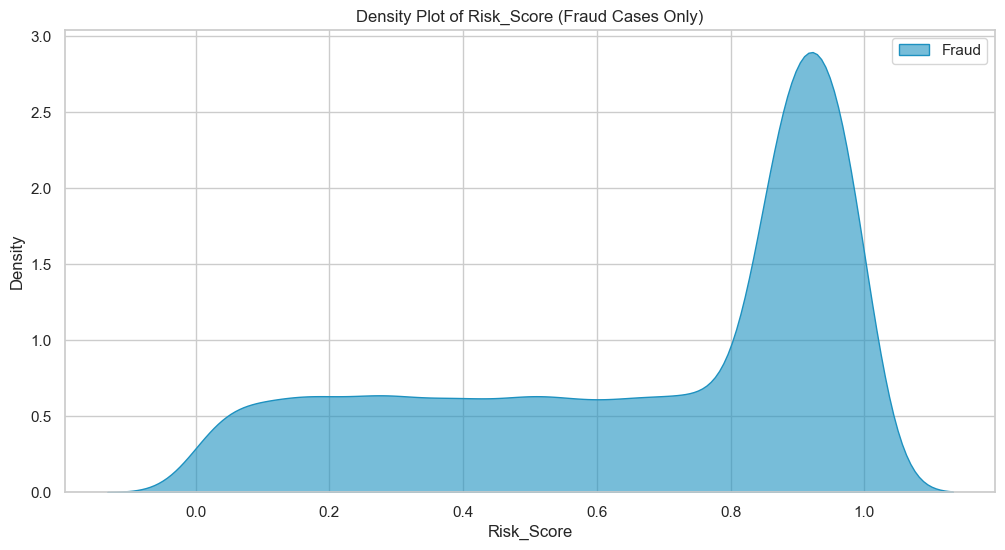

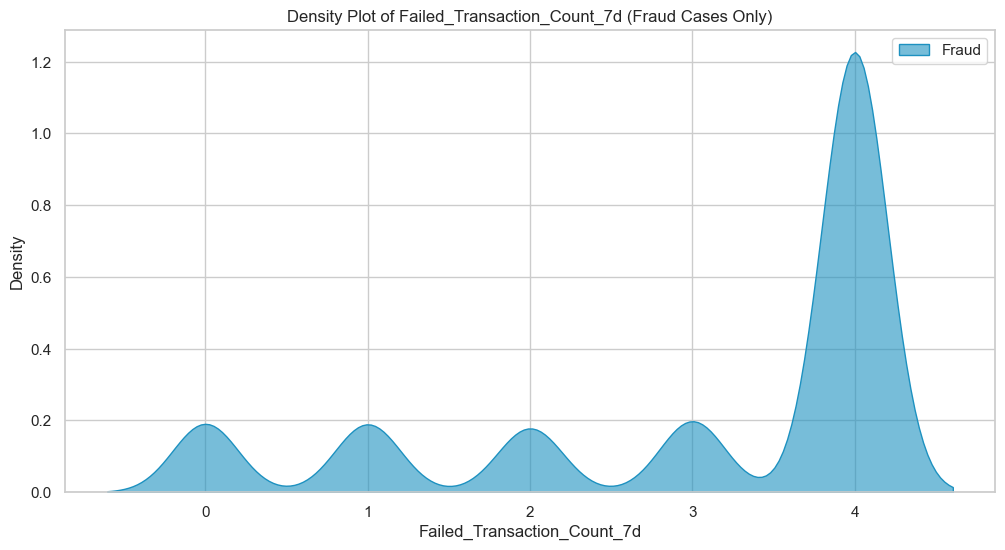

In [353]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# ---- 1️ Load & Prepare Data ----
features = ['Risk_Score', 'Failed_Transaction_Count_7d']
target = 'Fraud_Label'

X = df[features]
y = df[target]

X = X.apply(pd.to_numeric, errors='coerce').dropna()
y = y.loc[X.index]  # Align target with features

# ---- 2️ Train-Test Split ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- 3️ Train Logistic Regression Model ----
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# ---- 4️ Predict with Adjusted Threshold ----
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]
new_threshold = 0.3
y_pred_adjusted = (y_pred_prob >= new_threshold).astype(int)

# ---- 5️ Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred_adjusted)
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraud", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Threshold 0.3")
plt.show()

# ---- 6️ Probability Distribution Plot ----
plt.figure(figsize=(10, 6))
sns.kdeplot(y_pred_prob[y_test == 1], color="#1D91C0", fill=True, alpha=0.5, label="Fraud")
sns.kdeplot(y_pred_prob[y_test == 0], color="#7FCDBB", fill=True, alpha=0.5, label="Non-Fraud")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Density")
plt.title("Distribution of Predicted Fraud Probabilities (Threshold 0.3)")
plt.legend()
plt.show()

# ---- 7️ Precision-Recall Curve ----
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color="#1D91C0", label="Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.show()

# ---- 8️ Actual vs. Predicted Scatter Plot (Fraud Cases Only) ----

# Risk Score - Fraud Cases
plt.figure(figsize=(12, 6))
sns.scatterplot(x=X_test['Risk_Score'][y_test == 1], y=y_test[y_test == 1], color="#7FCDBB", alpha=0.6, label="Actual Fraud")
sns.scatterplot(x=X_test['Risk_Score'][y_pred_adjusted == 1], y=y_pred_adjusted[y_pred_adjusted == 1], color="#1D91C0", alpha=0.6, label="Predicted Fraud (Threshold=0.3)")
plt.title("Actual vs. Predicted Fraud (Risk Score) - Fraud Cases Only (Threshold 0.3)")
plt.xlabel("Risk Score")
plt.ylabel("Fraud (1)")
plt.legend()
plt.show()

# Failed Transactions (7d) - Fraud Cases
plt.figure(figsize=(12, 6))
sns.scatterplot(x=X_test['Failed_Transaction_Count_7d'][y_test == 1], y=y_test[y_test == 1], color="#7FCDBB", alpha=0.6, label="Actual Fraud")
sns.scatterplot(x=X_test['Failed_Transaction_Count_7d'][y_pred_adjusted == 1], y=y_pred_adjusted[y_pred_adjusted == 1], color="#1D91C0", alpha=0.6, label="Predicted Fraud (Threshold=0.3)")
plt.title("Actual vs. Predicted Fraud (Failed Transactions - 7d) - Fraud Cases Only (Threshold 0.3)")
plt.xlabel("Failed Transactions (Last 7 Days)")
plt.ylabel("Fraud (1)")
plt.legend()
plt.show()

# ---- 9️ Feature Distribution (Fraud Only) ----
for var in ['Risk_Score', 'Failed_Transaction_Count_7d']:
    plt.figure(figsize=(12, 6))
    sns.kdeplot(df[df['Fraud_Label'] == 1][var], color="#1D91C0", fill=True, alpha=0.6, label="Fraud")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.title(f"Density Plot of {var} (Fraud Cases Only)")
    plt.legend()
    plt.show()


#Brief Summary of Model Results (Logistic Regression with Threshold 0.3)

1: Model Type: Logistic Regression
Adjusted Threshold: 0.3 (instead of default 0.5 to catch more fraud cases)

2: Confusion Matrix Insights
- Shows classification performance at the 0.3 threshold.
- Useful for evaluating true positives (fraud caught) and false positives (non-fraud flagged).

3: Probability Distribution Plot
- Fraud cases tend to have higher predicted probabilities.
- Clear separation exists between fraud and non-fraud probability densities, though some overlap remains.

4: Precision-Recall Curve
- Highlights the tradeoff between capturing fraud (recall) and avoiding false alarms (precision).
- Useful in fraud detection where missing fraud is more costly than a few false alerts.

5: Actual vs. Predicted Plots
- For both Risk_Score and Failed_Transaction_Count_7d, predicted fraud aligns well with actual fraud when visualized.
- Some discrepancies suggest the model could still misclassify edge cases.

6: Density Plots (Fraud Only)
Fraud cases show:
- Higher and more variable risk scores
- More frequent failed transactions
- These features are strong indicators for detecting fraud.


🔹 Logistic Regression (Threshold = 0.3) Results 🔹
Confusion Matrix:
 [[5284 1481]
 [ 571 2664]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.78      0.84      6765
           1       0.64      0.82      0.72      3235

    accuracy                           0.79     10000
   macro avg       0.77      0.80      0.78     10000
weighted avg       0.82      0.79      0.80     10000



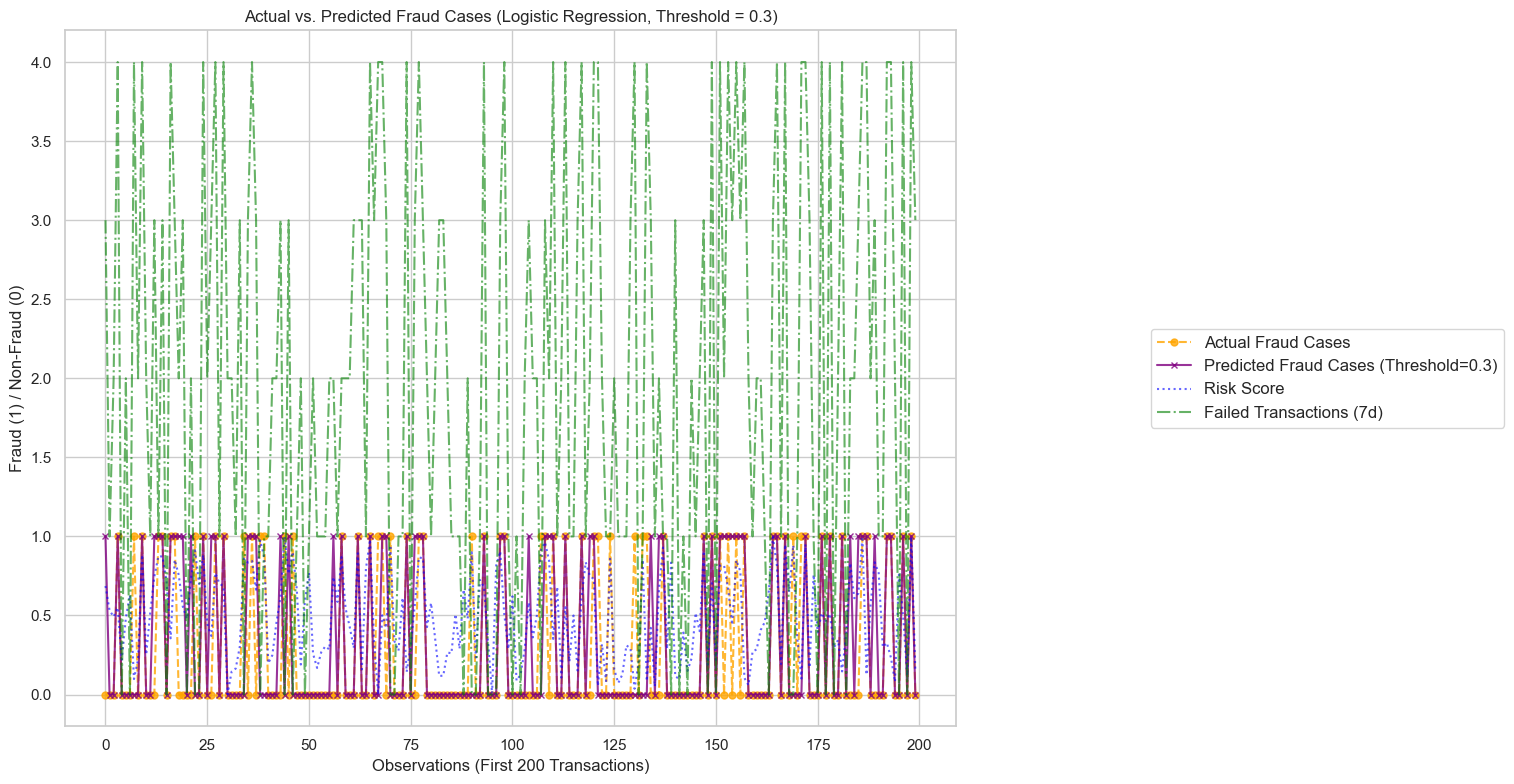

In [333]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: Load Data
df = pd.read_csv("synthetic_fraud_dataset.csv")

# Step 2: Select Features & Target
df = df[['Fraud_Label', 'Risk_Score', 'Failed_Transaction_Count_7d']]
df = df.dropna()  # Handle missing values

# Step 3: Define Independent (X) and Dependent (y) Variables
X = df[['Risk_Score', 'Failed_Transaction_Count_7d']]
y = df['Fraud_Label']

# Step 4: Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train Logistic Regression Model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Step 6: Get Predicted Probabilities
y_pred_prob = log_model.predict_proba(X_test)[:, 1]

# Step 7: Apply New Threshold (0.3)
threshold = 0.3
y_pred_adjusted = (y_pred_prob >= threshold).astype(int)

# Step 8: Evaluate Performance
print("\n🔹 Logistic Regression (Threshold = 0.3) Results 🔹")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_adjusted))
print("Classification Report:\n", classification_report(y_test, y_pred_adjusted))

# Step 9: Create Prediction Plot
plt.figure(figsize=(16, 8))

# Plot actual fraud cases
actual_plot, = plt.plot(y_test.values[:200], linestyle="--", color="orange", marker="o", markersize=5, alpha=0.8, label="Actual Fraud Cases")

# Plot predicted fraud cases
predicted_plot, = plt.plot(y_pred_adjusted[:200], linestyle="-", color="purple", marker="x", markersize=5, alpha=0.8, label="Predicted Fraud Cases (Threshold=0.3)")

# Plot top 2 features for reference
risk_score_plot, = plt.plot(X_test['Risk_Score'].values[:200], linestyle=":", color="blue", alpha=0.6, label="Risk Score")
failed_tx_plot, = plt.plot(X_test['Failed_Transaction_Count_7d'].values[:200], linestyle="-.", color="green", alpha=0.6, label="Failed Transactions (7d)")

# Labels & Styling
plt.xlabel("Observations (First 200 Transactions)")
plt.ylabel("Fraud (1) / Non-Fraud (0)")
plt.title("Actual vs. Predicted Fraud Cases (Logistic Regression, Threshold = 0.3)")

# **Ensure the legend includes all variables and appears on the right side**
plt.legend(handles=[actual_plot, predicted_plot, risk_score_plot, failed_tx_plot], loc='center left', bbox_to_anchor=(1.2, 0.5), fontsize=12, frameon=True, borderaxespad=1)

# Adjust layout for proper visibility
plt.tight_layout()

# Show Plot
plt.show()




# <span style="color:green">c: Fraud Prediction using Random Forest</span>

In [31]:
# Initialize RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest model using the scaled features
rf_classifier.fit(X_train_scaled, y_train)

# Predict fraud labels on the test set
y_pred_rf = rf_classifier.predict(X_test_scaled)

# Evaluate the performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Model Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6787
           1       1.00      1.00      1.00      3213

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


Confusion Matrix:
[[6787    0]
 [   0 3213]]


<br>

### <b> <span style="color:green">Interpretation of Fraud Classification Model Performance - Random Forest</span> </b>

<table border="1">
    <thead>
        <tr>
            <th>Class</th>
            <th>Precision</th>
            <th>Recall</th>
            <th>F1-Score</th>
            <th>Support</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Non-Fraud (0)</td>
            <td>1.00</td>
            <td>1.00</td>
            <td>1.00</td>
            <td>6787</td>
        </tr>
        <tr>
            <td>Fraud (1)</td>
            <td>1.00</td>
            <td>1.00</td>
            <td>1.00</td>
            <td>3213</td>
        </tr>
    </tbody>
</table>

<b> 1. Accuracy: 1.0000 </b>

The model correctly classifies 100% of transactions.
<br>
<br>
<b> 2. Classification Report Analysis </b>

<table border="1">
    <thead>
        <tr>
            <th><b>Subcategory</b></th>
            <th><b>Value</b></th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><b>a. Precision</b></td>
            <td><b>Fraud: 1.00, Non-Fraud: 1.00</b></td>
        </tr>
        <tr>
            <td colspan="2">
                Precision for fraud (1): 100% → When the model predicts fraud, it's correct 100% of the time.<br>
                Precision for non-fraud (0): 100% → When predicting legitimate transactions, it's correct 100% of the time.<br><br>
                Interpretation: There are no false positives in the model, meaning it correctly identifies both fraud and non-fraud cases without error.
            </td>
        </tr>
        <tr>
            <td><b>b. Recall</b></td>
            <td><b>Fraud: 1.00, Non-Fraud: 1.00</b></td>
        </tr>
        <tr>
            <td colspan="2">
                Recall for fraud (1): 100% → The model captures 100% of actual fraud cases.<br>
                Recall for non-fraud (0): 100% → It correctly identifies 100% of non-fraud transactions.<br><br>
                Interpretation: The model has no missed fraud cases or non-fraud transactions.
            </td>
        </tr>
        <tr>
            <td><b>c. F1-Score</b></td>
            <td><b>Fraud: 1.00, Non-Fraud: 1.00</b></td>
        </tr>
        <tr>
            <td colspan="2">
                The F1-score is the harmonic mean of precision and recall.<br>
                Since both precision and recall are perfect for both classes, the F1-score is also perfect (1.00).
            </td>
        </tr>
    </tbody>
</table>
<br>
<br>
<b> 3. Confusion Matrix Analysis</b>

True Positives (3213): Fraud cases correctly identified as fraud.<br>
True Negatives (6787): Non-fraud cases correctly identified as non-fraud.<br>
False Positives (0): Legitimate transactions incorrectly flagged as fraud.<br>
False Negatives (0): Fraud cases wrongly classified as non-fraud.<br>

<b>Key Observations </b>
- No false positives or false negatives were observed. The model has perfect classification performance.
<br>

<b> Overall Evaluation </b>
<br>
Strength:
- The model has perfect accuracy (1.0000) with flawless precision, recall, and F1-scores for both fraud and non-fraud classes.
- It does not make any classification errors, demonstrating exceptional performance.

Weaknesses & Areas for Improvement:
- Although the model performs perfectly here, the perfect performance may indicate overfitting, especially if evaluated on unseen data. To ensure robustness, the model should be tested with cross-validation or external test data.

## <span style="color:green">Validate Predictions </span>

### <span style="color:green"> Train and Predict with Logistic Regression & Random Forest</span>

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
df = pd.read_csv("synthetic_fraud_dataset.csv") 

# Drop irrelevant columns (IDs, timestamps, locations)
df_cleaned = df.drop(columns=["Transaction_ID", "User_ID", "Timestamp", "Location"], errors="ignore")

# Encode categorical variables
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

# Split independent (X) and dependent (y) variables
X = df_encoded.drop(columns=["Fraud_Label"])
y = df_encoded["Fraud_Label"]

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
df_encoded["Logistic_Prediction"] = log_reg.predict(X_scaled)
df_encoded["RandomForest_Prediction"] = rf_model.predict(X_scaled)

### <span style="color:green"> - Validate Predictions by Creating a Dual-Axis Plot</span>

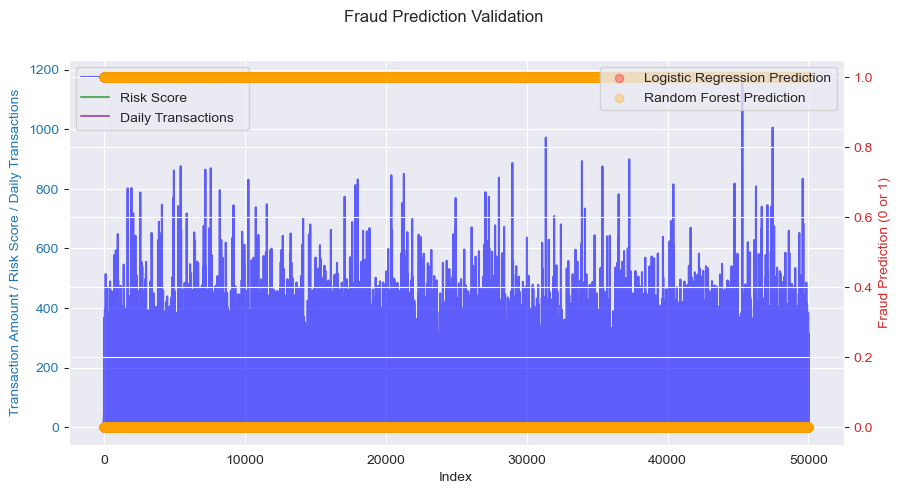

In [104]:
# Define the figure and axis
fig, ax1 = plt.subplots(figsize=(10,5))

# Primary Axis (Continuous Variables)
ax1.set_xlabel('Index')
ax1.set_ylabel('Transaction Amount / Risk Score / Daily Transactions', color='tab:blue')
ax1.plot(df_encoded.index, df_encoded["Transaction_Amount"], label='Transaction Amount', color='blue', alpha=0.6)
ax1.plot(df_encoded.index, df_encoded["Risk_Score"], label='Risk Score', color='green', alpha=0.6)
ax1.plot(df_encoded.index, df_encoded["Daily_Transaction_Count"], label='Daily Transactions', color='purple', alpha=0.6)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Secondary Axis (Predictions)
ax2 = ax1.twinx()  
ax2.set_ylabel('Fraud Prediction (0 or 1)', color='tab:red')
ax2.scatter(df_encoded.index, df_encoded["Logistic_Prediction"], label="Logistic Regression Prediction", color='red', alpha=0.3)
ax2.scatter(df_encoded.index, df_encoded["RandomForest_Prediction"], label="Random Forest Prediction", color='orange', alpha=0.3)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Titles and Legends
fig.suptitle('Fraud Prediction Validation')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show the plot
plt.show()

# <span style="color:green"> d: Using OLS Regression</span>

### <b> Evaluate Model Performance </b> 
<b> We use accuracy, precision, recall, and F1-score to measure performance. </b>

In [103]:
# Step 1: Reimport the data
df = pd.read_csv("synthetic_fraud_dataset.csv")

# Step 1: Ensure the dependent variable is numeric
dependent_variable = df['Fraud_Label']

# Step 2: Drop non-numeric columns or convert them
df = df.select_dtypes(include=[np.number])

# Step 3: Define independent variables
independent_variables = df.drop(columns=['Fraud_Label'])

# Step 4: Handle missing values
dataframe_raw = df.dropna()  # Drop rows with missing values, or use fillna()

# Step 5: Add a constant to the independent variables
independent_variables = sm.add_constant(independent_variables)

# Step 6: Fit the OLS regression model
regression_model = sm.OLS(dependent_variable, independent_variables).fit()

# Step 7: Print the regression model summary
print(regression_model.summary())

                            OLS Regression Results                            
Dep. Variable:            Fraud_Label   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                     3139.
Date:                Wed, 19 Mar 2025   Prob (F-statistic):               0.00
Time:                        10:54:57   Log-Likelihood:                -19745.
No. Observations:               50000   AIC:                         3.951e+04
Df Residuals:                   49988   BIC:                         3.962e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

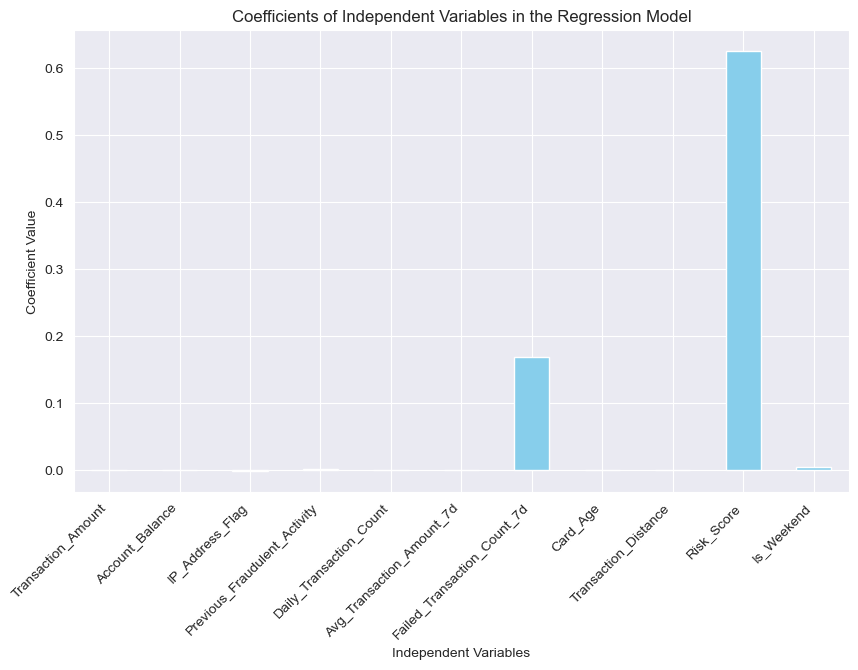

Risk_Score                     0.625492
Failed_Transaction_Count_7d    0.168283
Is_Weekend                     0.003943
dtype: float64


In [114]:
# Extract the coefficients (params) from the regression model
coefficients = regression_model.params

# Plot the coefficients using a bar chart
plt.figure(figsize=(10,6))
coefficients[1:].plot(kind='bar', color='skyblue')  # Exclude the constant term for visualization
plt.title("Coefficients of Independent Variables in the Regression Model")
plt.xlabel("Independent Variables")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45, ha='right')
plt.show()

# Identify the top 3 strongest variables in terms of absolute coefficient values
strongest_variables = coefficients[1:].abs().sort_values(ascending=False).head(3)
print(strongest_variables)

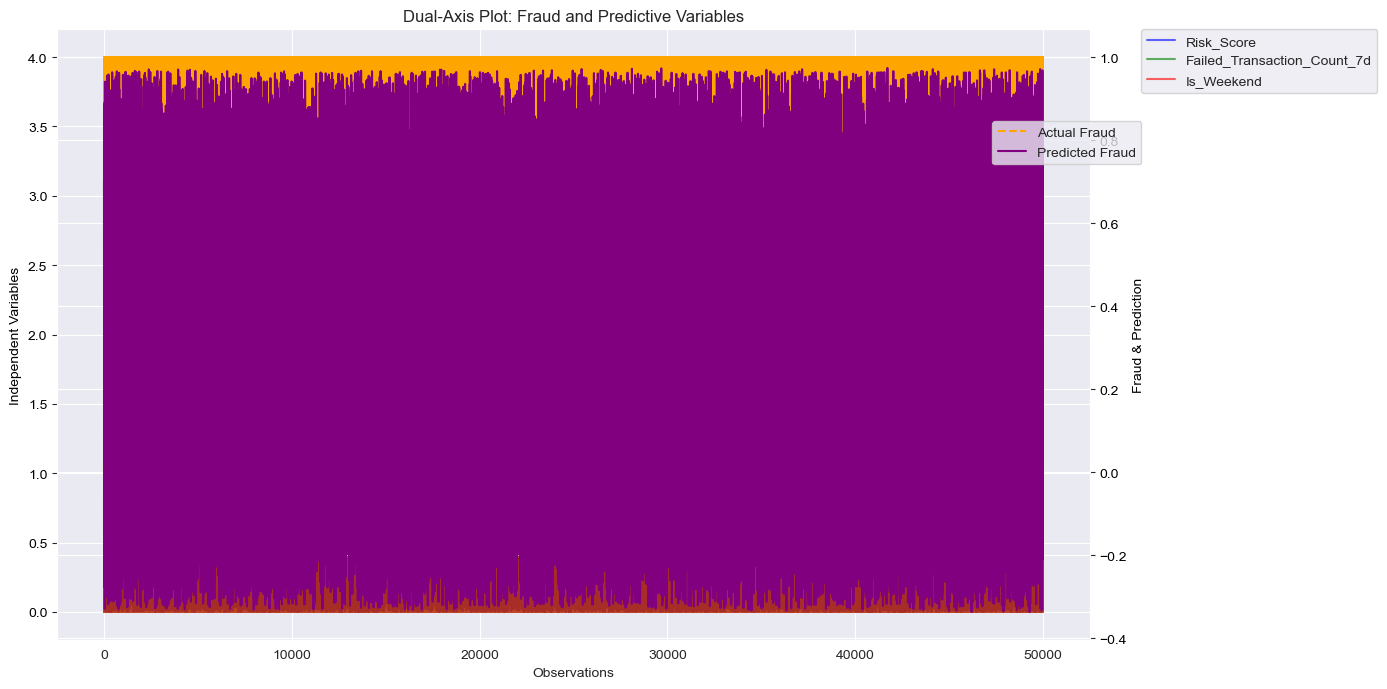

In [116]:
# Step 1: Ensure correct independent variables are used
train_columns = regression_model.model.exog_names  # Get trained model's column names
independent_vars_with_const = sm.add_constant(df.drop(columns=['Fraud_Label']), has_constant='add')

# Ensure columns match the trained model
independent_vars_with_const = independent_vars_with_const[train_columns]

# Predict the values using the regression model
df['Prediction'] = regression_model.predict(independent_vars_with_const)

# Step 2: Create a dual-axis plot
fig, ax1 = plt.subplots(figsize=(14, 7))  # Increased figure size

# Plot Axes One: Risk_Score, Failed_Transaction_Count_7d, and Is_Weekend
ax1.plot(df['Risk_Score'], label='Risk_Score', color='b', alpha=0.6)
ax1.plot(df['Failed_Transaction_Count_7d'], label='Failed_Transaction_Count_7d', color='g', alpha=0.6)
ax1.plot(df['Is_Weekend'], label='Is_Weekend', color='r', alpha=0.6)
ax1.set_xlabel("Observations")
ax1.set_ylabel("Independent Variables", color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis
ax2 = ax1.twinx()

# Plot Axes Two: Fraud_Label and Prediction
ax2.plot(df['Fraud_Label'], label='Actual Fraud', color='orange', linestyle='--')
ax2.plot(df['Prediction'], label='Predicted Fraud', color='purple', linestyle='-')
ax2.set_ylabel("Fraud & Prediction", color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add titles and legends
plt.title('Dual-Axis Plot: Fraud and Predictive Variables')

# Move legends outside the plot for better visibility
ax1.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
ax2.legend(loc='upper right', bbox_to_anchor=(1.05, 0.85), borderaxespad=0.)

# Adjust layout to prevent overlap
plt.tight_layout()

plt.show()

### <b> Removing Unnecessary Variables for Model Efficiency </b>

In [124]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Step 1: Reimport the data
df = pd.read_csv("synthetic_fraud_dataset.csv")

# Step 2: Ensure only numeric data is used
df = df.select_dtypes(include=[np.number])  # Keep only numeric columns

# Step 3: Define dependent and independent variables
dependent_variable = df['Fraud_Label']

# **Keep only Risk_Score and Failed_Transaction_Count_7d for better model efficiency**
independent_variables = df[['Risk_Score', 'Failed_Transaction_Count_7d']]

# Step 4: Handle missing values (drop rows with NaN values)
independent_variables = independent_variables.dropna()
dependent_variable = dependent_variable.loc[independent_variables.index]  # Align indices

# Step 5: Add a constant to independent variables
independent_variables = sm.add_constant(independent_variables)

# Step 6: Fit the OLS regression model
regression_model = sm.OLS(dependent_variable, independent_variables).fit()

# Step 7: Print the regression model summary
print(regression_model.summary())

                            OLS Regression Results                            
Dep. Variable:            Fraud_Label   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                 1.726e+04
Date:                Wed, 19 Mar 2025   Prob (F-statistic):               0.00
Time:                        11:10:56   Log-Likelihood:                -19747.
No. Observations:               50000   AIC:                         3.950e+04
Df Residuals:                   49997   BIC:                         3.953e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [359]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Load Data
df = pd.read_csv("synthetic_fraud_dataset.csv")

# Step 2: Select Relevant Columns
df = df[['Fraud_Label', 'Risk_Score', 'Failed_Transaction_Count_7d']]

# Step 3: Handle Missing Values
df = df.dropna()

# Step 4: Define Independent and Dependent Variables
X = df[['Risk_Score', 'Failed_Transaction_Count_7d']]
y = df['Fraud_Label']

# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train Linear Regression Model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Step 7: Make Predictions and Convert to Binary
y_pred_prob = lin_model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)  # Apply threshold

# Step 8: Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Step 9: Print Results
print(f"Linear Regression Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)


Linear Regression Accuracy: 0.8027

Confusion Matrix:
 [[5937  828]
 [1145 2090]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      6765
           1       0.72      0.65      0.68      3235

    accuracy                           0.80     10000
   macro avg       0.78      0.76      0.77     10000
weighted avg       0.80      0.80      0.80     10000



<!DOCTYPE html>
<html>
<head>
    <style>
        body {
            font-family: Arial, sans-serif;
            margin: 40px;
            line-height: 1.6;
        }
        h2 {
            color: #2E8B57;
            text-align: center;
        }
        h3 {
            color: #333;
            margin-top: 20px;
        }
        table {
            width: 80%;
            border-collapse: collapse;
            margin: 20px auto;
            font-size: 18px;
            text-align: left;
        }
        th, td {
            padding: 10px;
            border: 1px solid #ddd;
        }
        th {
            background-color: #4CAF50;
            color: white;
        }
        tr:nth-child(even) {
            background-color: #f2f2f2;
        }
        .summary {
            font-size: 18px;
            font-weight: bold;
            text-align: center;
            margin-top: 20px;
        }
        ul {
            margin: 10px 0 20px 20px;
        }
    </style>
</head>
<body>

<h2>Fraud Classification Model Performance - Linear Regression</h2>

<div class="summary"> The model correctly classifies ~80.27% of transactions.</div>

<h3> Classification Metrics</h3>

<table>
    <thead>
        <tr>
            <th>Class</th>
            <th>Precision</th>
            <th>Recall</th>
            <th>F1-Score</th>
            <th>Support</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Non-Fraud (0)</td>
            <td>0.84</td>
            <td>0.88</td>
            <td>0.86</td>
            <td>6,765</td>
        </tr>
        <tr>
            <td>Fraud (1)</td>
            <td>0.72</td>
            <td>0.65</td>
            <td>0.68</td>
            <td>3,235</td>
        </tr>
    </tbody>
</table>

<h3> Classification Report Summary</h3>

<ul>
    <li><b>Accuracy:</b> 80.27%</li>
    <li><b>Precision:</b>
        <ul>
            <li><b>Fraud (1) = 72%</b> → When the model predicts fraud, it is correct 72% of the time.</li>
            <li><b>Non-Fraud (0) = 84%</b> → When predicting legitimate transactions, it's correct 84% of the time.</li>
        </ul>
    </li>
    <li><b>Recall:</b>
        <ul>
            <li><b>Fraud (1) = 65%</b> → The model captures 65% of actual fraud cases but misses 35%.</li>
            <li><b>Non-Fraud (0) = 88%</b> → It correctly identifies 88% of non-fraud transactions.</li>
        </ul>
    </li>
    <li><b>F1-Score:</b>
        <ul>
            <li><b>Fraud (1) = 0.68</b> → Indicates a moderate level of fraud detection performance.</li>
            <li><b>Non-Fraud (0) = 0.86</b> → Strong performance in detecting legitimate transactions.</li>
        </ul>
    </li>
</ul>

<h3> Confusion Matrix Breakdown</h3>

<table>
    <thead>
        <tr>
            <th>Prediction</th>
            <th>Non-Fraud (0)</th>
            <th>Fraud (1)</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><b>Actual Non-Fraud (0)</b></td>
            <td>5,937 ✅</td>
            <td>828 ❌ (False Positive)</td>
        </tr>
        <tr>
            <td><b>Actual Fraud (1)</b></td>
            <td>1,145 ❌ (False Negative)</td>
            <td>2,090 ✅</td>
        </tr>
    </tbody>
</table>

<h3> Observations & Key Takeaways</h3>

<ul>
    <li><b>✅ Strengths:</b>
        <ul>
            <li>The model performs well in identifying non-fraud transactions (88% recall).</li>
            <li>Reasonable fraud precision at 72% with balanced performance overall.</li>
        </ul>
    </li>
    <li><b>❌ Areas for Improvement:</b>
        <ul>
            <li><b>False Negatives:</b> 1,145 fraud cases were missed.</li>
            <li><b>False Positives:</b> 828 legitimate transactions were incorrectly flagged as fraud.</li>
            <li>Improving fraud recall (currently 65%) would increase reliability for real-world applications.</li>
        </ul>
    </li>
</ul>

</body>
</html>

